# E3 — Batch: Batch Size
## Pregunta de investigación

¿Cómo afecta el batch size al throughput y TTFT?

## Hipótesis previa

Mayor batch_size puede mejorar throughput pero no debería afectar TTFT individual.

## Configuración del experimento

| Parámetro | Valores             |
|-----------|---------------------|
| Modelo | Todos                  |
| Batch Size | 128, 256, 512, 1024,2048,4096,51 |
| Total | Múltiples runs      |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Carga de datos (E3) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "TFG-DATA" / "E3"

assert DATA_ROOT.is_dir(), f"No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados E3: {len(coll)}")

# --- Filtrado para E3: todos los modelos × batch_size, sin acelerador ---
summary = coll.summary_df()
hw_full = coll.hw_metrics_df()
pm_full = coll.prompt_metrics_df()

ex = summary[
    (summary["test_type"] == "TYPE_3") &
    (summary["accelerator"] == False)
].copy()

# Fallback si no hay TYPE_3
if ex.empty:
    ex = summary[summary["accelerator"] == False].copy()

print(f"Runs en E3: {ex.shape[0]}")
if len(ex) > 0:
    print(f"Modelos:    {sorted(ex['model_label'].unique())}")
    print(f"Batch sizes:{sorted(ex['batch_size'].dropna().unique())}")
else:
    print("Sin datos disponibles para este experimento.")


Runs cargados E3: 30
Runs en E3: 30
Modelos:    ['DeepSeek-R1-1.5B (L)', 'Llama-3.2-1B (L)', 'Llama-3.2-3B (L)', 'gemma (L)', 'granite (L)', 'ministral (L)']
Batch sizes:[np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048)]


# 📊 Figuras y tablas de la memoria

Serie E3 — efecto del **batch size** sobre el rendimiento de Llama-3.2-1B.
El material complementario está en el **📎 Anexo** al final.

| # | Figura/Tabla |
|---|---|
| T1 | Tabla maestra E3: batch_size × métricas (tok/s, TTFT, J/tok, MBU, η, FoM, Usable) |
| 1  | Throughput (tok/s) vs batch_size + umbral de usabilidad T_hum |
| 2  | TTFT (ms) vs batch_size |
| 3  | Coste energético (J/tok) vs batch_size |
| 4  | FoM_full vs batch_size |


In [2]:
# ── E3 Tabla maestra — modelo × batch_size × métricas ────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability

_fom_e3 = compute_fom_full(ex)
_pm_ex  = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
if not _pm_ex.empty and not _fom_e3.empty:
    _fom_e3, _ = compute_usability(_fom_e3, _pm_ex)

# σ desde métricas por prompt (variabilidad intra-run)
if not _pm_ex.empty and "run_id" in _pm_ex.columns and "run_id" in _fom_e3.columns:
    _valid_pm3 = (_pm_ex[~_pm_ex["is_empty_generation"]]
                  if "is_empty_generation" in _pm_ex.columns else _pm_ex)
    _std_cols3 = [c for c in ["tokens_per_second", "time_to_first_token_ms", "perplexity"]
                  if c in _valid_pm3.columns]
    if _std_cols3:
        _std_df3 = (
            _valid_pm3.groupby("run_id")[_std_cols3].std().reset_index()
            .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                             "time_to_first_token_ms": "ttft_ms_std",
                             "perplexity":             "perplexity_std"})
        )
        _fom_e3 = _fom_e3.merge(_std_df3, on="run_id", how="left")

# Añadir uso de RAM (max por run) desde hw_full
if not hw_full.empty and "run_id" in hw_full.columns and "mem_used_bytes" in hw_full.columns:
    _ram_agg = (hw_full.groupby("run_id")[["mem_used_bytes","mem_pct"]]
                .max().reset_index())
    _ram_agg["mem_used_gb"] = (_ram_agg["mem_used_bytes"] / 1e9).round(2)
    _fom_e3 = _fom_e3.merge(
        _ram_agg[["run_id","mem_used_gb","mem_pct"]], on="run_id", how="left")

_tab_cols = {
    "model_label":        "Modelo",
    "batch_size":         "Batch",
    "tokens_per_s_mean":  "tok/s",
    "tokens_per_s_std":   "σ tok/s",
    "ttft_ms_mean":       "TTFT (ms)",
    "ttft_ms_std":        "σ TTFT",
    "energy_per_token_j": "J/tok",
    "mbu_corr":           "MBU (%)",
    "mem_used_gb":        "RAM (GB)",
    "mem_pct":            "RAM (%)",
    "cpu_efficiency":     "η_CPU",
    "fom_full":           "FoM_full",
}
if "usable" in _fom_e3.columns:
    _tab_cols["usable"] = "Usable"

_t = (_fom_e3[[c for c in _tab_cols if c in _fom_e3.columns]]
        .rename(columns=_tab_cols)
        .sort_values(["Modelo","Batch"])
        .set_index(["Modelo","Batch"])
        .round(3))
if "Usable" in _t.columns:
    _t["Usable"] = _t["Usable"].map({True: "✓", False: "✗"})
print("E3 — Tabla maestra (todos los modelos × batch_size)")
display(_t)


E3 — Tabla maestra (todos los modelos × batch_size)


tok/s  σ tok/s  TTFT (ms)    σ TTFT  J/tok  MBU (%)  RAM (GB)  RAM (%)  η_CPU  FoM_full Usable
Modelo               Batch                                                                                                 
DeepSeek-R1-1.5B (L) 128     9.053    1.262    949.630   555.057  0.779   64.248      1.64   19.430  0.974     1.031      ✓
                     256     9.122    1.217    941.503   556.243  0.761   64.831      1.64   19.362  0.974     1.041      ✓
                     512     9.080    1.227    949.567   556.352  0.763   64.507      1.54   18.238  0.974     1.038      ✓
                     1024    9.018    1.272    951.968   555.797  0.766   63.975      1.66   19.594  0.974     1.033      ✓
                     2048    9.171    1.143    948.265   555.249  0.758   65.312      1.53   18.092  0.974     1.045      ✓
Llama-3.2-1B (L)     128    11.262    2.466    673.012   364.654  0.582   58.970      1.40   16.543  0.975     0.956      ✓
                     256    11.252    2.360    675.105   365.580  0.573   59.182      1.49   17.656  0.975     0.960      ✓
                     512    11.208    2.435    675.105   363.270  0.584   58.742      1.49   17.609  0.975     0.953      ✓
                     1024   11.246    2.454    675.101   363.431  0.583   58.923      1.38   16.354  0.975     0.955      ✓
                     2048   11.322    2.402    670.258   365.624  0.579   59.487      1.40   16.593  0.975     0.961      ✓
Llama-3.2-3B (L)     128     4.600    1.097   1941.750  1202.823  1.450   62.446      3.03   35.892  0.987     0.998      ✓
                     256     4.594    1.091   1939.671  1202.281  1.462   62.409      3.02   35.740  0.987     0.996      ✓
                     512     4.623    1.101   1931.589  1203.380  1.453   62.774      3.00   35.494  0.987     1.000      ✓
                     1024    4.617    1.118   1940.837  1205.438  1.437   62.526      3.00   35.535  0.987     1.002      ✓
                     2048    4.606    1.096   1934.278  1214.247  1.442   62.556      3.12   36.950  0.987     1.000      ✓
gemma (L)            128     5.677    0.084   2611.181  1883.493  1.220   55.407      2.30   27.158  0.946     0.813      ✓
                     256     5.715    0.107   2597.384  1882.447  1.207   55.772      2.34   27.706  0.946     0.818      ✓
                     512     5.694    0.082   2612.048  1880.147  1.224   55.574      2.36   27.955  0.946     0.814      ✓
                     1024    5.684    0.080   2610.034  1880.591  1.221   55.481      2.28   26.939  0.946     0.814      ✓
                     2048    5.689    0.087   2611.307  1882.398  1.215   55.523      2.34   27.731  0.946     0.815      ✓
granite (L)          128     4.403    0.054   2352.064  1604.863  1.519   52.885      2.53   29.885  0.968     0.928      ✓
                     256     4.475    0.075   2328.028  1611.364  1.489   53.737      2.49   29.508  0.968     0.941      ✓
                     512     4.402    0.048   2355.078  1609.430  1.534   52.875      2.56   30.287  0.968     0.926      ✓
                     1024    4.412    0.047   2360.083  1606.135  1.526   52.988      2.58   30.460  0.968     0.928      ✓
                     2048    4.438    0.082   2343.745  1608.110  1.522   53.300      2.61   30.901  0.968     0.931      ✓
ministral (L)        128     4.726    0.701   1927.368  1298.973  1.433   66.117      3.12   36.961  0.980     1.054      ✓
                     256     4.738    0.701   1922.815  1295.890  1.416   66.321      3.19   37.722  0.979     1.059      ✓
                     512     4.705    0.693   1926.126  1300.303  1.420   65.900      3.16   37.348  0.980     1.054      ✓
                     1024    4.725    0.708   1924.960  1295.591  1.433   66.062      3.07   36.332  0.980     1.054      ✓
                     2048    4.736    0.707   1930.748  1316.724  1.412   66.221      3.07   36.367  0.980     1.059      ✓

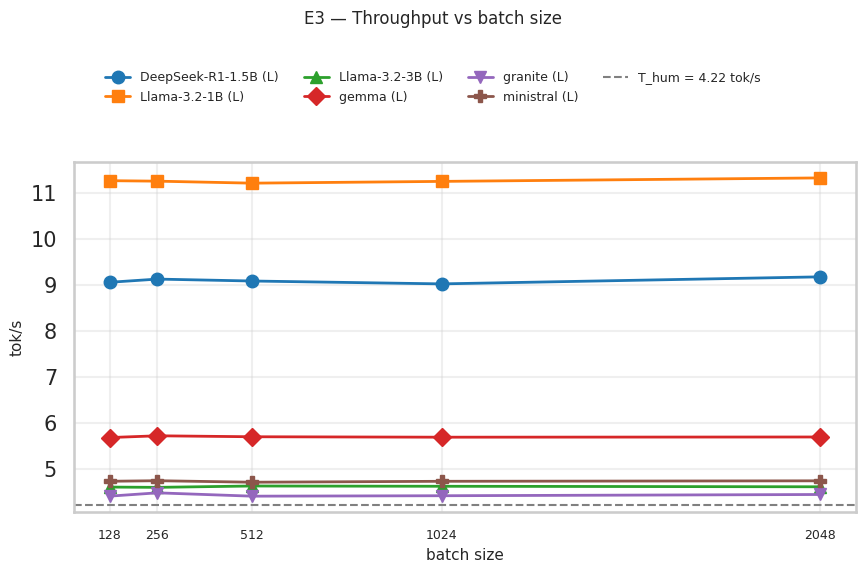

Exportado: figures/05_Resultados/E3/e3_tps_vs_batch.png


In [3]:
# ── E3 — Throughput vs batch size ─────────────────────────────────────────────────────────────
import os
_export = "figures/05_Resultados/E3/e3_tps_vs_batch.png"

if not _fom_e3.empty and "batch_size" in _fom_e3.columns and "tokens_per_s_mean" in _fom_e3.columns:
    _models = sorted(_fom_e3["model_label"].unique())
    _MODEL_PAL = {m: c for m, c in zip(_models,
        ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink"])}
    _MARKERS = ["o","s","^","D","v","P","X"]
    _MOD_MK  = {m: _MARKERS[i % len(_MARKERS)] for i, m in enumerate(_models)}

    fig, ax = plt.subplots(figsize=(9, 5))
    for model in _models:
        _sub = _fom_e3[_fom_e3["model_label"]==model].sort_values("batch_size")
        if _sub.empty or _sub["tokens_per_s_mean"].isna().all(): continue
        ax.plot(_sub["batch_size"], _sub["tokens_per_s_mean"],
                marker=_MOD_MK[model], lw=2, label=model, color=_MODEL_PAL[model])
    if "T_hum" in _fom_e3.columns:
        _thum = _fom_e3["T_hum"].dropna().mean()
        ax.axhline(_thum, ls="--", color="grey", lw=1.5,
                   label=f"T_hum = {_thum:.2f} tok/s")

    _bs_ticks = sorted(_fom_e3["batch_size"].dropna().unique())
    ax.set_xticks(_bs_ticks)
    ax.set_xticklabels([str(int(b)) for b in _bs_ticks], fontsize=9)
    ax.set_xlabel("batch size", fontsize=11)
    ax.set_ylabel("tok/s", fontsize=11)
    ax.grid(True, alpha=0.3)

    fig.legend(fontsize=9, loc="upper center",
               bbox_to_anchor=(0.5, 1.06), ncol=min(len(_models)+1, 4))
    fig.suptitle("E3 — Throughput vs batch size", fontsize=12, y=1.16)
    plt.tight_layout()
    os.makedirs(os.path.dirname(_export), exist_ok=True)
    fig.savefig(_export, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export}")
else:
    print("Sin datos de tokens_per_s_mean o batch_size.")


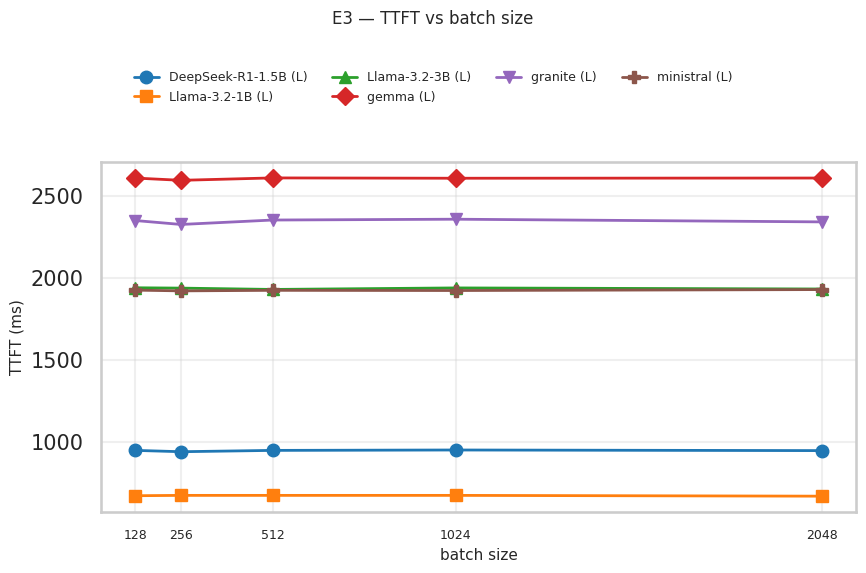

Exportado: figures/05_Resultados/E3/e3_ttft_vs_batch.png


In [4]:
# ── E3 — TTFT vs batch size ─────────────────────────────────────────────────────────────
import os
_export = "figures/05_Resultados/E3/e3_ttft_vs_batch.png"

if not _fom_e3.empty and "batch_size" in _fom_e3.columns and "ttft_ms_mean" in _fom_e3.columns:
    _models = sorted(_fom_e3["model_label"].unique())
    _MODEL_PAL = {m: c for m, c in zip(_models,
        ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink"])}
    _MARKERS = ["o","s","^","D","v","P","X"]
    _MOD_MK  = {m: _MARKERS[i % len(_MARKERS)] for i, m in enumerate(_models)}

    fig, ax = plt.subplots(figsize=(9, 5))
    for model in _models:
        _sub = _fom_e3[_fom_e3["model_label"]==model].sort_values("batch_size")
        if _sub.empty or _sub["ttft_ms_mean"].isna().all(): continue
        ax.plot(_sub["batch_size"], _sub["ttft_ms_mean"],
                marker=_MOD_MK[model], lw=2, label=model, color=_MODEL_PAL[model])

    _bs_ticks = sorted(_fom_e3["batch_size"].dropna().unique())
    ax.set_xticks(_bs_ticks)
    ax.set_xticklabels([str(int(b)) for b in _bs_ticks], fontsize=9)
    ax.set_xlabel("batch size", fontsize=11)
    ax.set_ylabel("TTFT (ms)", fontsize=11)
    ax.grid(True, alpha=0.3)

    # Leyenda fuera arriba, título encima de la leyenda (sin solapamiento)
    fig.legend(fontsize=9, loc="upper center",
               bbox_to_anchor=(0.5, 1.06), ncol=min(len(_models), 4))
    fig.suptitle("E3 — TTFT vs batch size", fontsize=12, y=1.16)
    plt.tight_layout()
    os.makedirs(os.path.dirname(_export), exist_ok=True)
    fig.savefig(_export, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export}")
else:
    print("Sin datos de ttft_ms_mean o batch_size.")


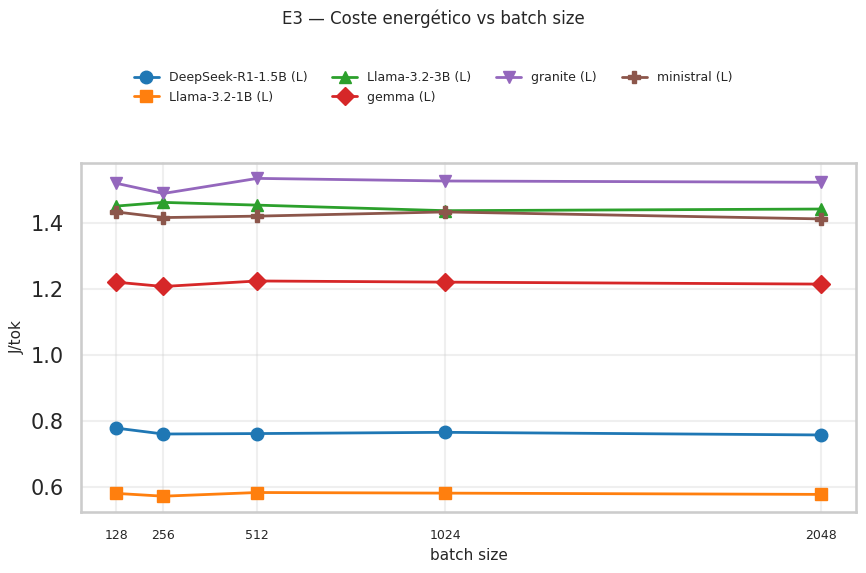

Exportado: figures/05_Resultados/E3/e3_energy_vs_batch.png


In [5]:
# ── E3 — Coste energético vs batch size ─────────────────────────────────────────────────────────────
import os
_export = "figures/05_Resultados/E3/e3_energy_vs_batch.png"

if not _fom_e3.empty and "batch_size" in _fom_e3.columns and "energy_per_token_j" in _fom_e3.columns:
    _models = sorted(_fom_e3["model_label"].unique())
    _MODEL_PAL = {m: c for m, c in zip(_models,
        ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink"])}
    _MARKERS = ["o","s","^","D","v","P","X"]
    _MOD_MK  = {m: _MARKERS[i % len(_MARKERS)] for i, m in enumerate(_models)}

    fig, ax = plt.subplots(figsize=(9, 5))
    for model in _models:
        _sub = _fom_e3[_fom_e3["model_label"]==model].sort_values("batch_size")
        if _sub.empty or _sub["energy_per_token_j"].isna().all(): continue
        ax.plot(_sub["batch_size"], _sub["energy_per_token_j"],
                marker=_MOD_MK[model], lw=2, label=model, color=_MODEL_PAL[model])

    _bs_ticks = sorted(_fom_e3["batch_size"].dropna().unique())
    ax.set_xticks(_bs_ticks)
    ax.set_xticklabels([str(int(b)) for b in _bs_ticks], fontsize=9)
    ax.set_xlabel("batch size", fontsize=11)
    ax.set_ylabel("J/tok", fontsize=11)
    ax.grid(True, alpha=0.3)

    fig.legend(fontsize=9, loc="upper center",
               bbox_to_anchor=(0.5, 1.06), ncol=min(len(_models), 4))
    fig.suptitle("E3 — Coste energético vs batch size", fontsize=12, y=1.16)
    plt.tight_layout()
    os.makedirs(os.path.dirname(_export), exist_ok=True)
    fig.savefig(_export, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export}")
else:
    print("Sin datos de energy_per_token_j o batch_size.")


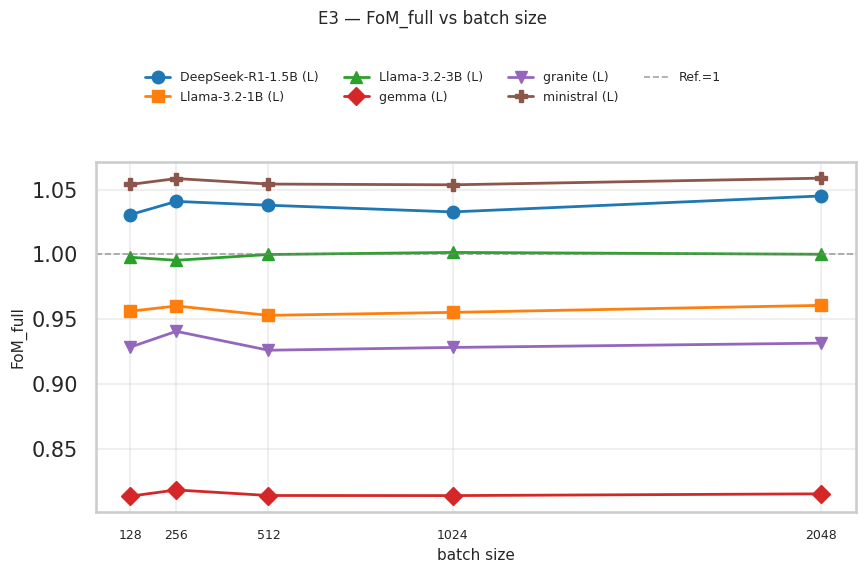

Exportado: figures/05_Resultados/E3/e3_fom_vs_batch.png


In [6]:
# ── E3 — FoM_full vs batch size ─────────────────────────────────────────────────────────────
import os
_export = "figures/05_Resultados/E3/e3_fom_vs_batch.png"

if not _fom_e3.empty and "batch_size" in _fom_e3.columns and "fom_full" in _fom_e3.columns:
    _models = sorted(_fom_e3["model_label"].unique())
    _MODEL_PAL = {m: c for m, c in zip(_models,
        ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink"])}
    _MARKERS = ["o","s","^","D","v","P","X"]
    _MOD_MK  = {m: _MARKERS[i % len(_MARKERS)] for i, m in enumerate(_models)}

    fig, ax = plt.subplots(figsize=(9, 5))
    for model in _models:
        _sub = _fom_e3[_fom_e3["model_label"]==model].sort_values("batch_size")
        if _sub.empty or _sub["fom_full"].isna().all(): continue
        ax.plot(_sub["batch_size"], _sub["fom_full"],
                marker=_MOD_MK[model], lw=2, label=model, color=_MODEL_PAL[model])
    ax.axhline(1.0, ls="--", color="grey", lw=1.2, alpha=0.7, label="Ref.=1")

    _bs_ticks = sorted(_fom_e3["batch_size"].dropna().unique())
    ax.set_xticks(_bs_ticks)
    ax.set_xticklabels([str(int(b)) for b in _bs_ticks], fontsize=9)
    ax.set_xlabel("batch size", fontsize=11)
    ax.set_ylabel("FoM_full", fontsize=11)
    ax.grid(True, alpha=0.3)

    fig.legend(fontsize=9, loc="upper center",
               bbox_to_anchor=(0.5, 1.06), ncol=min(len(_models)+1, 4))
    fig.suptitle("E3 — FoM_full vs batch size", fontsize=12, y=1.16)
    plt.tight_layout()
    os.makedirs(os.path.dirname(_export), exist_ok=True)
    fig.savefig(_export, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export}")
else:
    print("Sin datos de fom_full o batch_size.")


---
# 📎 ANEXO — Material complementario (no incluido en la memoria principal)
---

Las siguientes celdas contienen análisis exploratorios, validaciones y figuras
complementarias que fundamentan los resultados de la sección principal.


## Resumen ejecutivo
> TODO: Actualizar con resultados finales.

In [7]:
# ── Anexo: Tablas comparativas E3 (inferencia + hardware con σ) ─────
if not ex.empty:
    from monitorviz.transforms.fom import compute_fom_full, compute_usability

    _df_ann = ex.copy()

    # σ inferencia desde pm_full por prompt
    if not pm_full.empty and "run_id" in pm_full.columns and "run_id" in _df_ann.columns:
        _valid_ann = (pm_full[~pm_full["is_empty_generation"]]
                      if "is_empty_generation" in pm_full.columns else pm_full)
        _si_ann = [c for c in ["tokens_per_second","time_to_first_token_ms","perplexity"]
                   if c in _valid_ann.columns]
        if _si_ann:
            _std_inf_ann = (_valid_ann.groupby("run_id")[_si_ann].std().reset_index()
                            .rename(columns={
                                "tokens_per_second":      "tokens_per_s_std",
                                "time_to_first_token_ms": "ttft_ms_std",
                                "perplexity":             "perplexity_std",
                            }))
            _df_ann = _df_ann.merge(_std_inf_ann, on="run_id", how="left")

    # σ hardware desde hw_full por muestra
    if not hw_full.empty and "run_id" in hw_full.columns and "run_id" in _df_ann.columns:
        _sh_ann = [c for c in ["temperature_c","internal_power_w","freq_mean_ghz"]
                   if c in hw_full.columns]
        if _sh_ann:
            _std_hw_ann = (hw_full.groupby("run_id")[_sh_ann].std().reset_index()
                           .rename(columns={
                               "temperature_c":   "temp_std_c",
                               "internal_power_w": "power_std_w",
                               "freq_mean_ghz":   "freq_std_ghz",
                           }))
            _df_ann = _df_ann.merge(_std_hw_ann, on="run_id", how="left")

    if "usable" in _df_ann.columns:
        _df_ann["usable"] = _df_ann["usable"].map({True: "✓", False: "✗"})

    # Tabla 1 — Inferencia con σ
    _inf_cols_ann = [c for c in [
        "model_label", "batch_size", "engine",
        "tokens_per_s_mean",    "tokens_per_s_std",
        "ttft_ms_mean",         "ttft_ms_std",
        "latency_ms_mean",
        "perplexity_geomean",   "perplexity_std",
    ] if c in _df_ann.columns]
    print("Tabla comparativa E3 — Inferencia")
    display(_df_ann[_inf_cols_ann].sort_values(["model_label","batch_size"]).round(3).reset_index(drop=True))

    # Tabla 2 — Hardware con σ
    _hw_cols_ann = [c for c in [
        "model_label", "batch_size", "engine",
        "temp_max_c",       "temp_mean_c",  "temp_std_c",
        "power_mean_w",     "power_std_w",
        "freq_std_ghz",
        "throttled_ratio",
        "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
    ] if c in _df_ann.columns]
    print("\nTabla comparativa E3 — Hardware")
    display(_df_ann[_hw_cols_ann].sort_values(["model_label","batch_size"]).round(3).reset_index(drop=True))
else:
    print("Sin datos.")


Tabla comparativa E3 — Inferencia


,model_label,batch_size,engine,tokens_per_s_mean,tokens_per_s_std,ttft_ms_mean,ttft_ms_std,latency_ms_mean,perplexity_geomean,perplexity_std
0,DeepSeek-R1-1.5B (L),128,LLAMA,9.053,1.262,949.630,555.057,351182.609,2.751,0.931
1,DeepSeek-R1-1.5B (L),256,LLAMA,9.122,1.217,941.503,556.243,347274.732,2.751,0.931
2,DeepSeek-R1-1.5B (L),512,LLAMA,9.080,1.227,949.567,556.352,349199.758,2.751,0.931
3,DeepSeek-R1-1.5B (L),1024,LLAMA,9.018,1.272,951.968,555.797,352862.439,2.751,0.931
4,DeepSeek-R1-1.5B (L),2048,LLAMA,9.171,1.143,948.265,555.249,343642.407,2.751,0.931
5,Llama-3.2-1B (L),128,LLAMA,11.262,2.466,673.012,364.654,208262.450,2.360,1.265
6,Llama-3.2-1B (L),256,LLAMA,11.252,2.360,675.105,365.580,205769.542,2.360,1.265
7,Llama-3.2-1B (L),512,LLAMA,11.208,2.435,675.105,363.270,208654.373,2.360,1.265
8,Llama-3.2-1B (L),1024,LLAMA,11.246,2.454,675.101,363.431,208185.156,2.360,1.265
9,Llama-3.2-1B (L),2048,LLAMA,11.322,2.402,670.258,365.624,205194.303,2.360,1.265



Tabla comparativa E3 — Hardware


,model_label,batch_size,engine,temp_max_c,temp_mean_c,temp_std_c,power_mean_w,power_std_w,freq_std_ghz,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
0,DeepSeek-R1-1.5B (L),128,LLAMA,74.35,70.812,1.533,7.054,0.878,0.0,0.0,0.779,20587.826,0.974
1,DeepSeek-R1-1.5B (L),256,LLAMA,69.95,66.051,1.369,6.944,0.884,0.0,0.0,0.761,20357.038,0.974
2,DeepSeek-R1-1.5B (L),512,LLAMA,71.05,67.528,1.293,6.925,0.870,0.0,0.0,0.763,20470.015,0.974
3,DeepSeek-R1-1.5B (L),1024,LLAMA,69.95,67.291,1.217,6.911,0.865,0.0,0.0,0.766,20687.132,0.974
4,DeepSeek-R1-1.5B (L),2048,LLAMA,70.50,67.233,1.188,6.956,0.869,0.0,0.0,0.758,20138.342,0.974
5,Llama-3.2-1B (L),128,LLAMA,71.05,66.101,1.847,6.551,0.948,0.0,0.0,0.582,12234.097,0.975
6,Llama-3.2-1B (L),256,LLAMA,69.40,65.025,1.546,6.450,0.936,0.0,0.0,0.573,12083.806,0.975
7,Llama-3.2-1B (L),512,LLAMA,71.05,66.037,1.740,6.550,0.945,0.0,0.0,0.584,12256.807,0.975
8,Llama-3.2-1B (L),1024,LLAMA,69.95,65.884,1.745,6.552,0.947,0.0,0.0,0.583,12229.055,0.975
9,Llama-3.2-1B (L),2048,LLAMA,69.40,64.919,1.382,6.552,0.953,0.0,0.0,0.579,12049.559,0.975


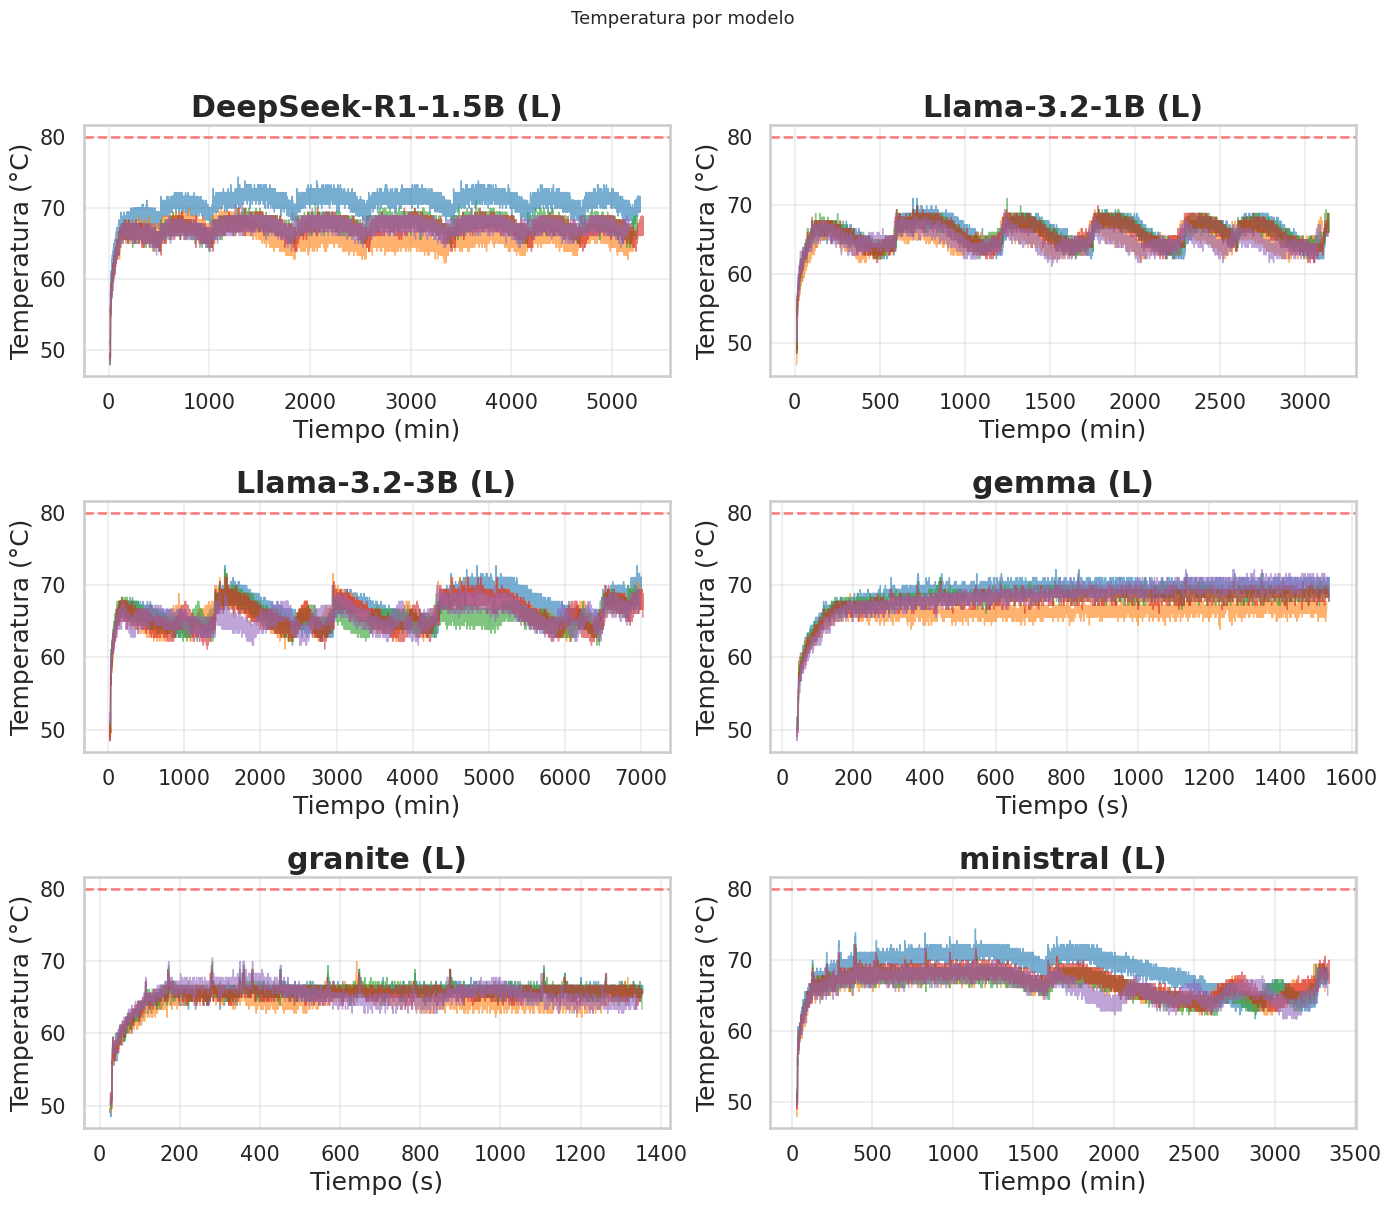

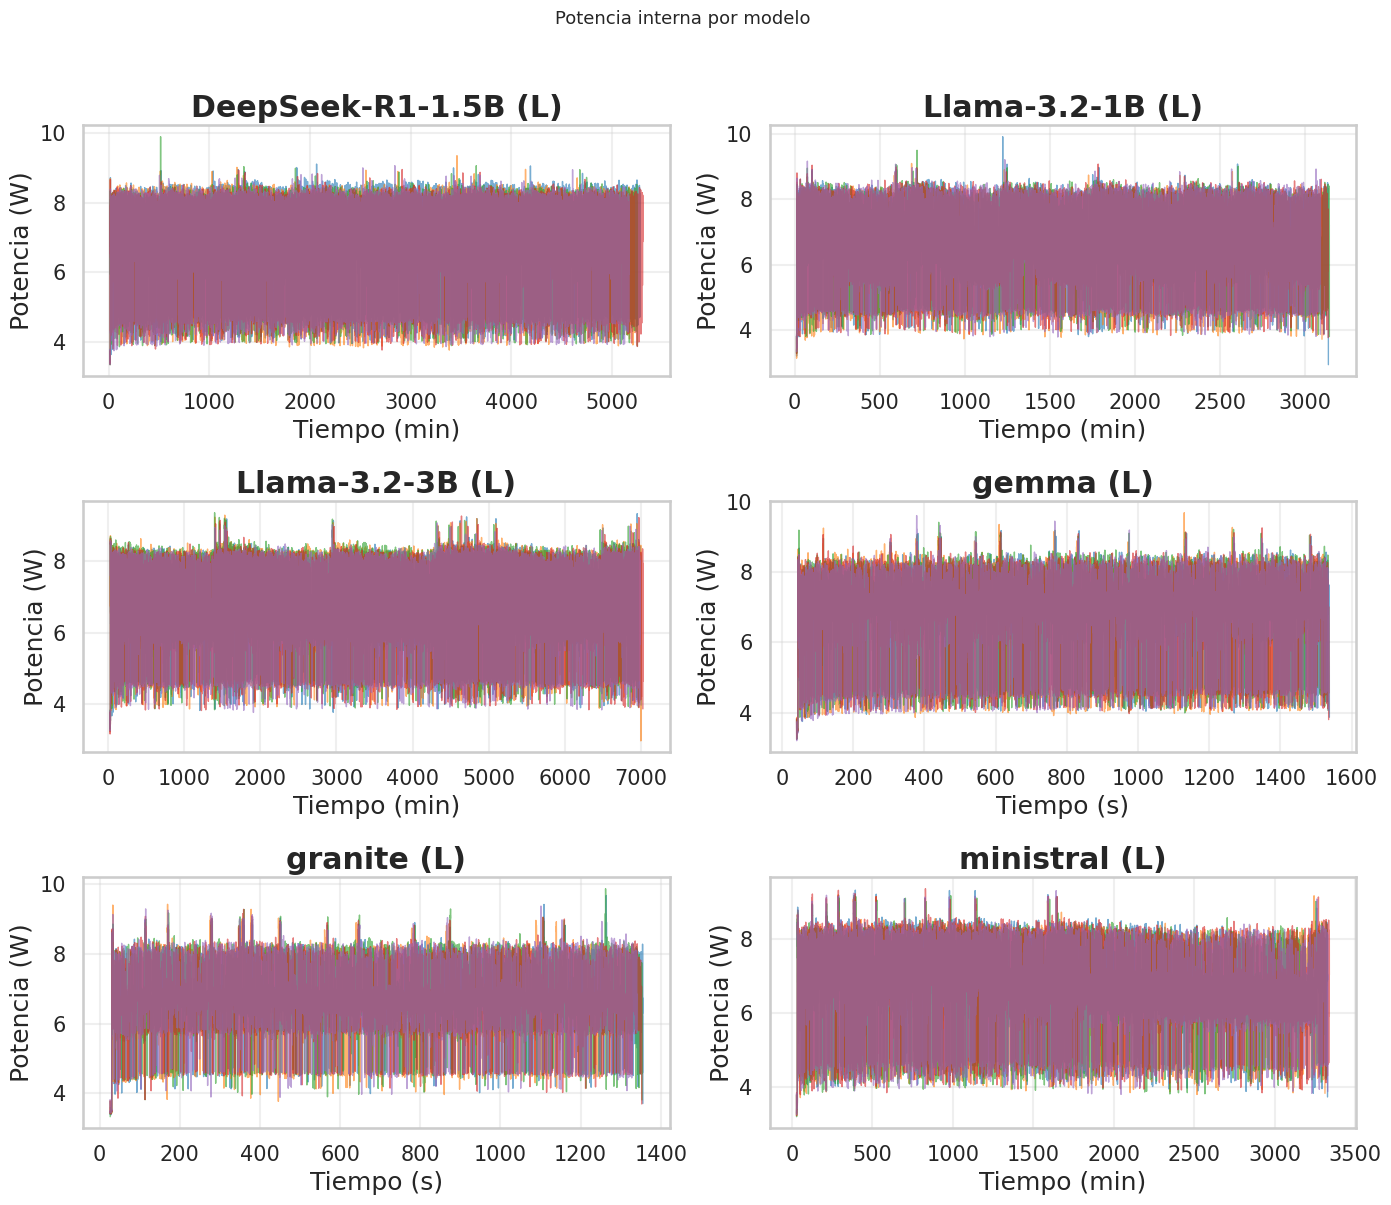

In [8]:
# Timelines de temperatura y potencia (small multiples, 2 columnas)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        # Plot each run separately (fast matplotlib lines, no seaborn aggregation)
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub[y_col].values, alpha=0.6, linewidth=1)
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5)
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Tiempo (min)" if total_s > 1800 else "Tiempo (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperatura (°C)",
                   "Temperatura por modelo", hline=80)
    _plot_timeline(hw_ex, models, "internal_power_w", "Potencia (W)",
                   "Potencia interna por modelo")
else:
    print("Sin datos de hardware para timelines")

/tmp/ipykernel_729383/98568102.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_729383/98568102.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


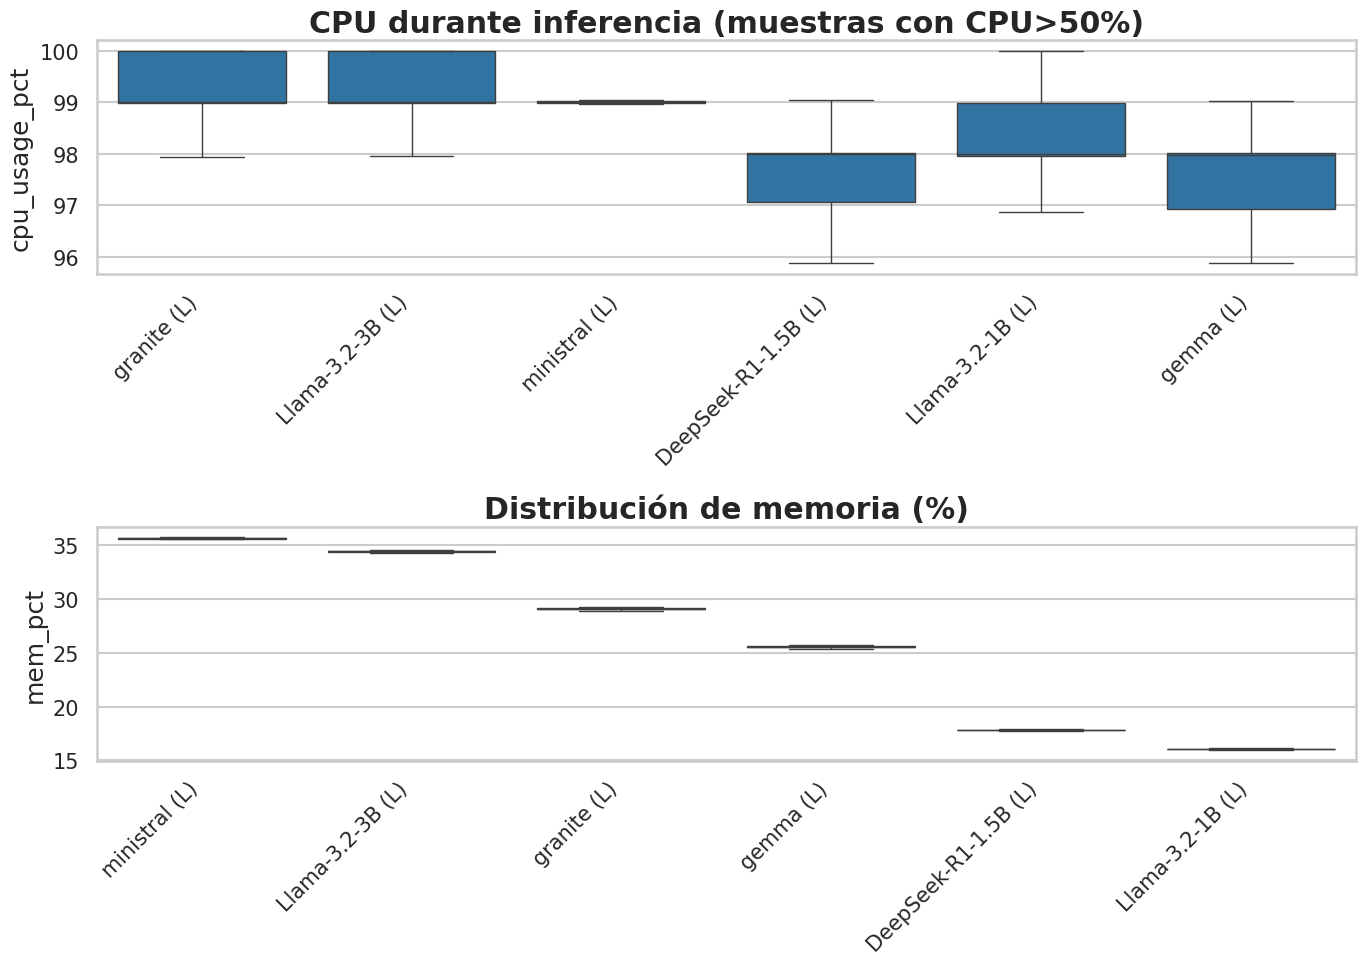

/tmp/ipykernel_729383/98568102.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_729383/98568102.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


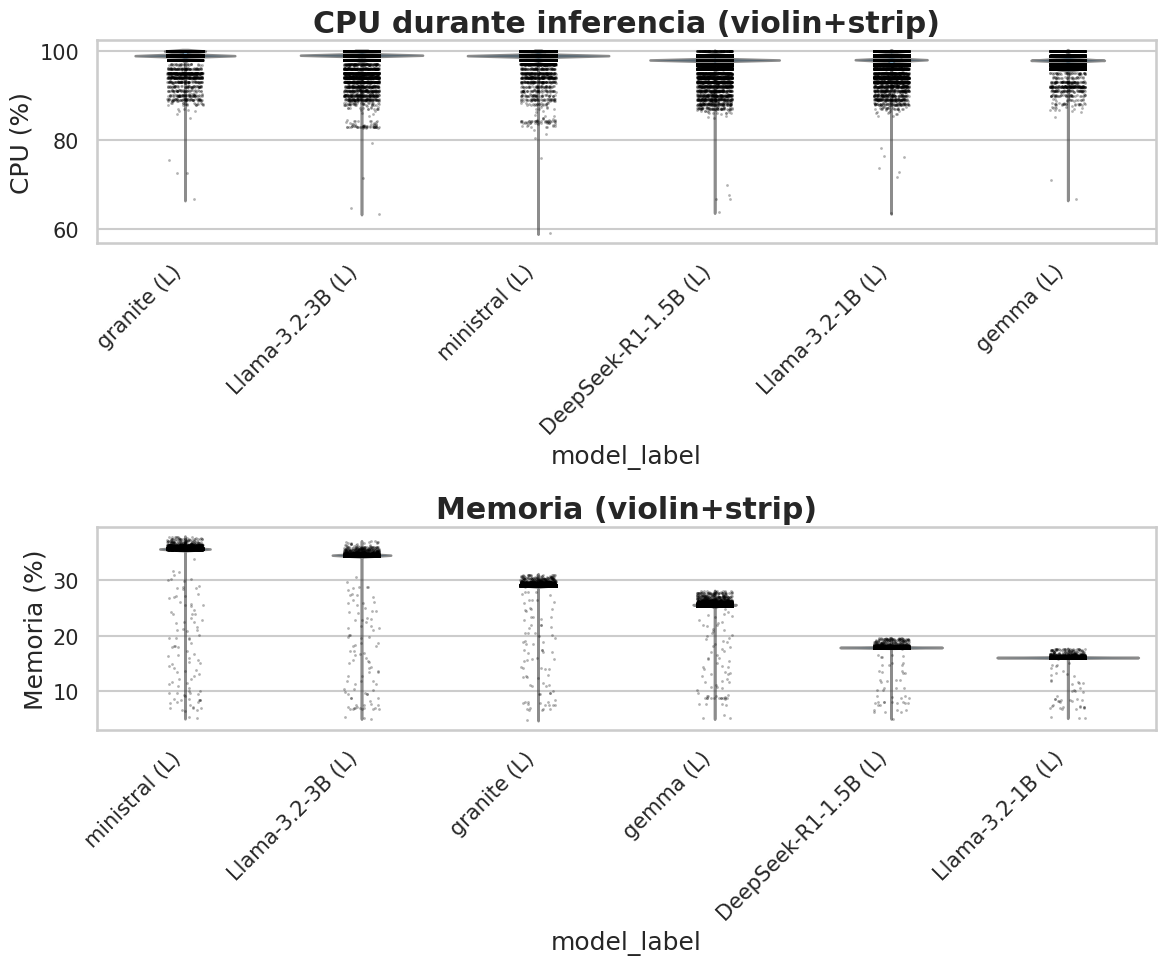

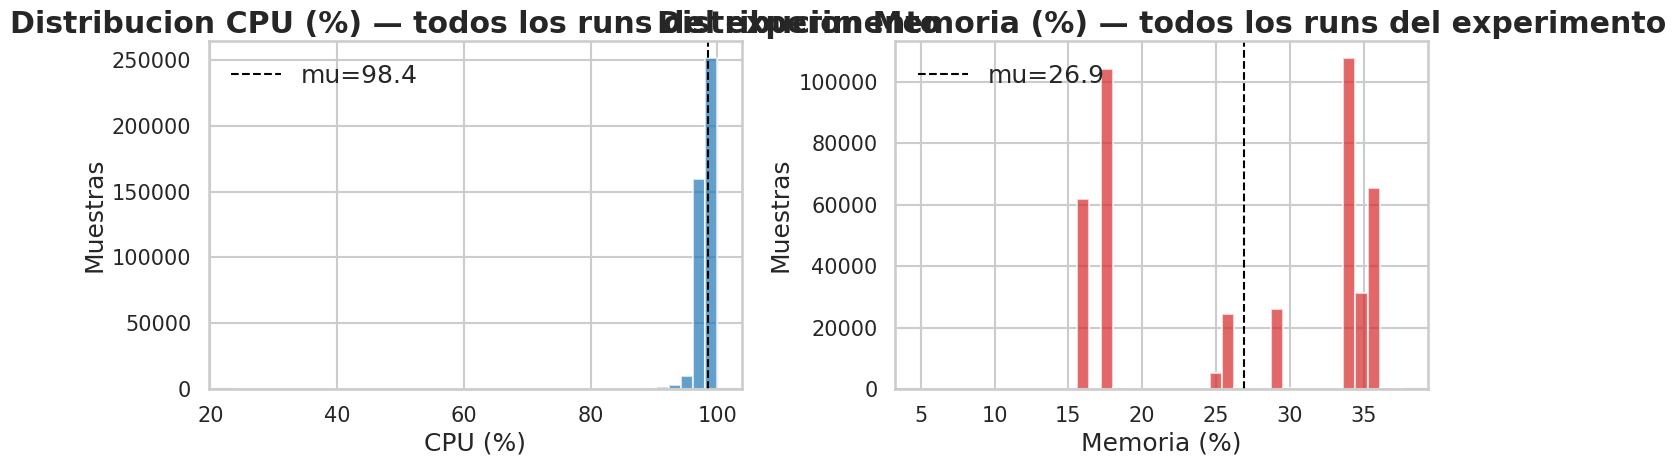

In [9]:
# Sección 5a — Boxplot CPU y Memoria
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=active, x="model_label", y="cpu_usage_pct",
                order=order_cpu, showfliers=False, ax=axes[0])
    axes[0].set_title("CPU durante inferencia (muestras con CPU>50%)")
    axes[0].set_xlabel("")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct",
                order=order_mem, showfliers=False, ax=axes[1])
    axes[1].set_title("Distribución de memoria (%)")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    plt.show()

    # Sección 5b — Violin + strip
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index
                 if not active.empty else [])
    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
                       order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
                      order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU durante inferencia (violin+strip)")
        axes[0].set_ylabel("CPU (%)")
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index)
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct",
                   order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct",
                  order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memoria (violin+strip)")
    axes[1].set_ylabel("Memoria (%)")
    fig.tight_layout()
    plt.show()

    # Sección 5c — Histogramas agregados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ("cpu_usage_pct", "CPU (%)", "tab:blue"),
        ("mem_pct", "Memoria (%)", "tab:red"),
    ]):
        active_hist = hw_ex[hw_ex["cpu_usage_pct"] > 10]
        data = active_hist[col].dropna()
        if not data.empty:
            ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                       label=f"mu={data.mean():.1f}")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Muestras")
            ax.set_title(f"Distribucion {xlabel} — todos los runs del experimento")
            ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para distribuciones CPU/Memoria")

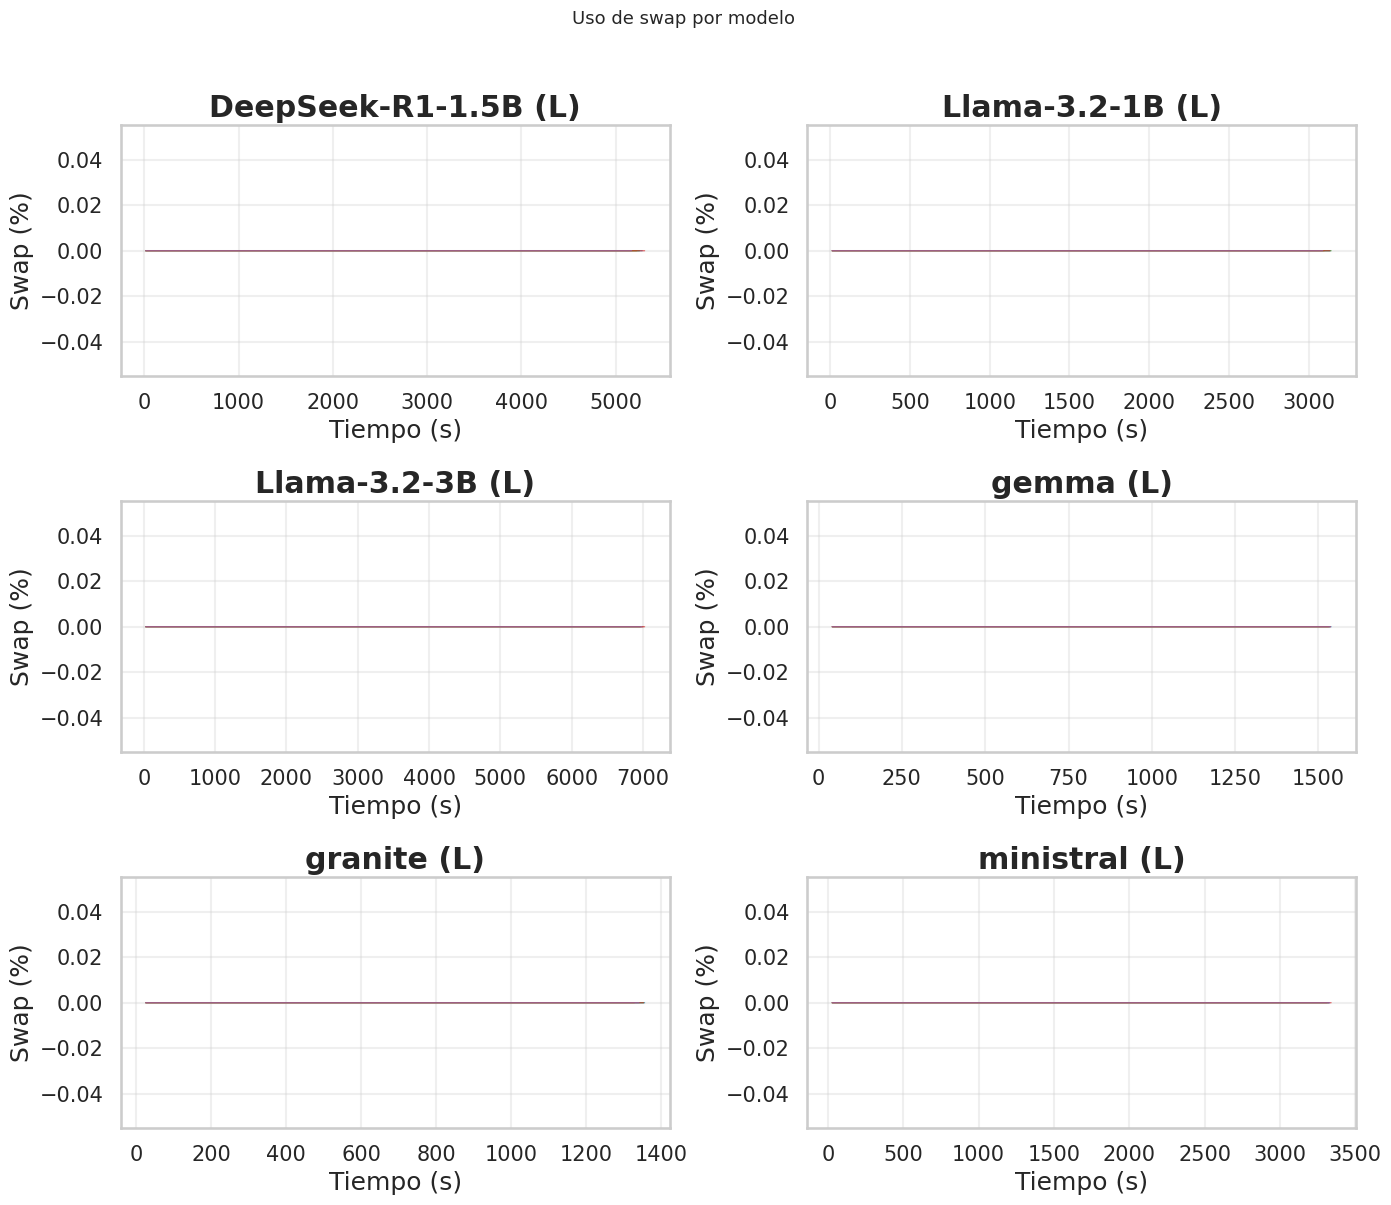

In [10]:
# Swap por modelo (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Uso de swap por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para swap")

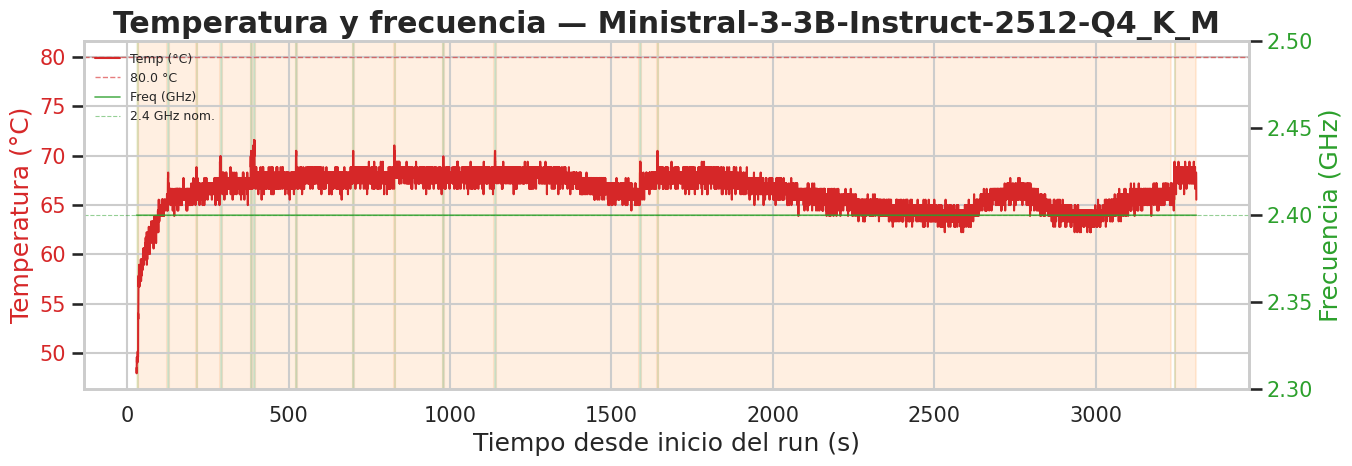

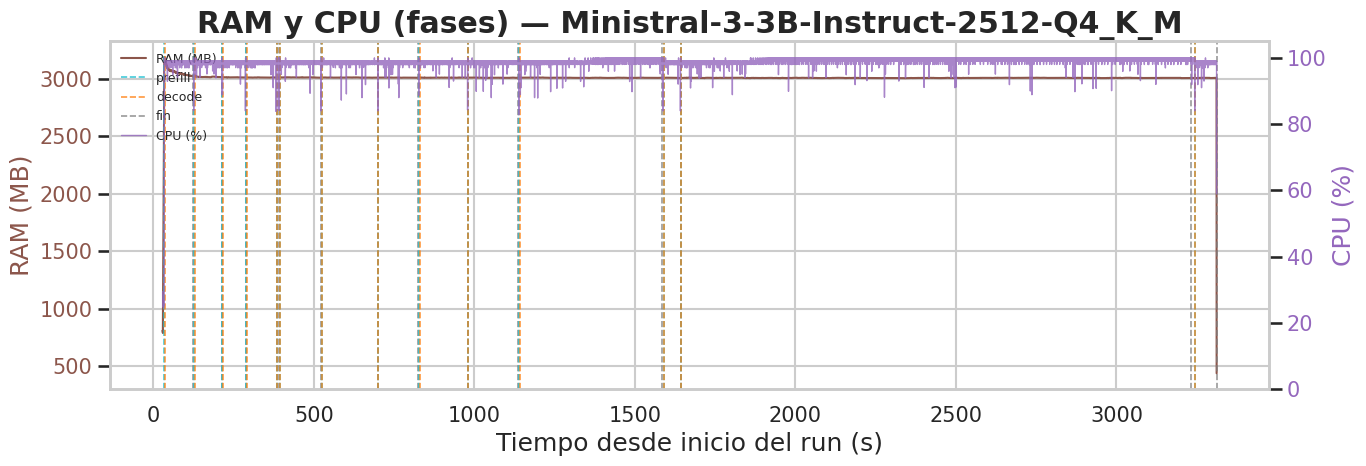

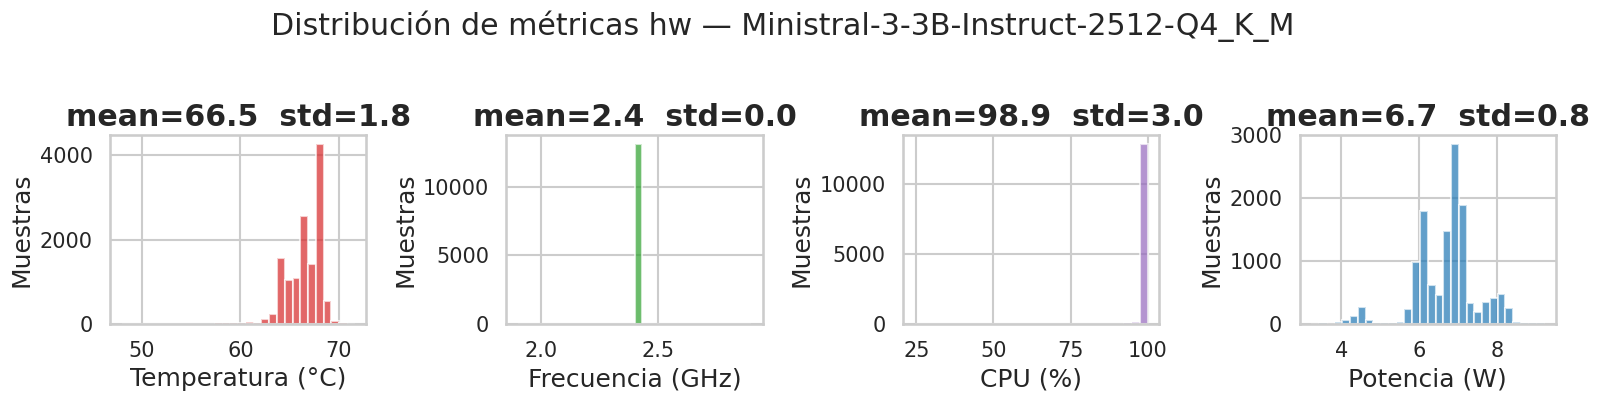

In [11]:
# Análisis detallado de un run representativo (mediana de duración)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No se encontro run representativo")
else:
    print("Sin datos para análisis detallado")

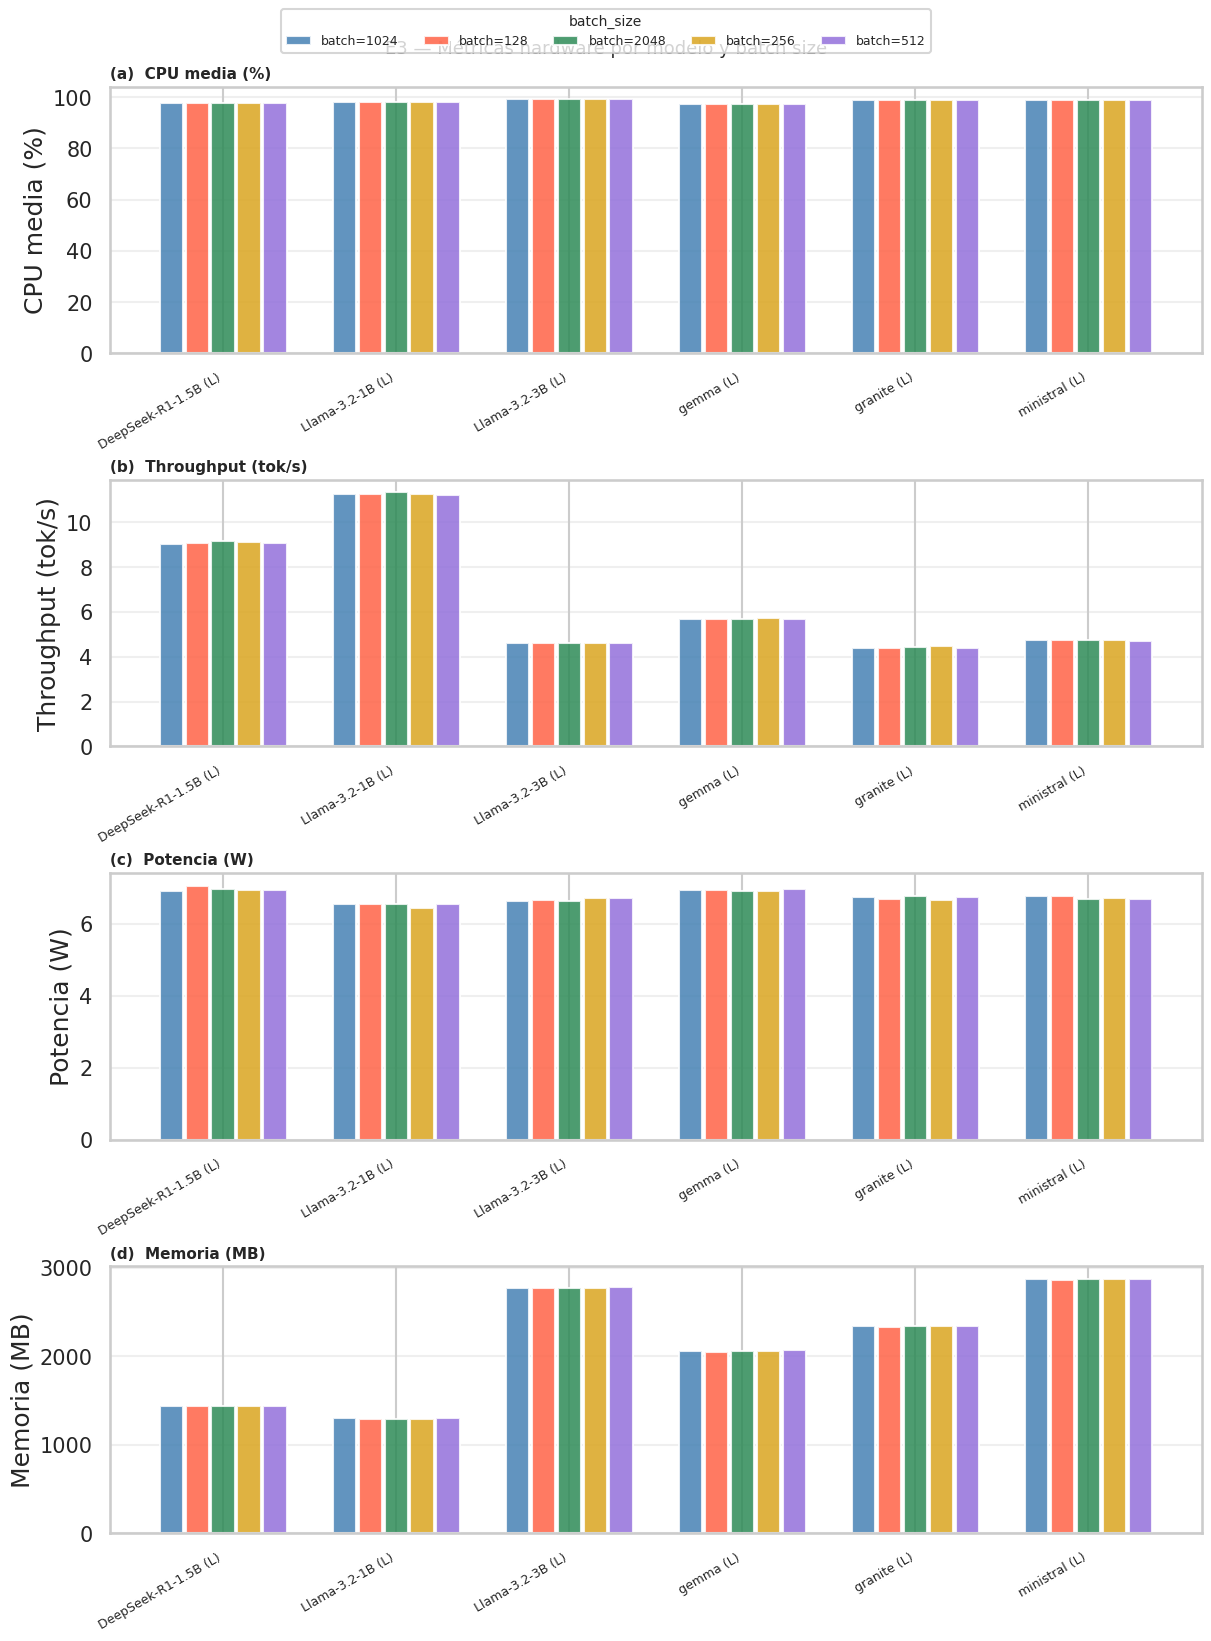

In [12]:
# Grouped bar chart hardware (4 paneles: CPU%, Throughput, Potencia, Memoria)
import re

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
    (pm_full["run_id"].isin(_run_ids)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
] if "run_id" in pm_full.columns else pd.DataFrame())
for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue
    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()
    if hw_r.empty:
        continue
    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    group_label = str(int(row.get("batch_size", 0))) if not pd.isna(row.get("batch_size", float("nan"))) else "?"
    hw_summary_rows.append({
        "model": row["model_label"],
        "config": group_label,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w": hw_r["internal_power_w"].mean(),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024**2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)
    METRICS = [
        ("cpu_pct",  "CPU media (%)",      "(a)"),
        ("tokens_s", "Throughput (tok/s)", "(b)"),
        ("power_w",  "Potencia (W)",       "(c)"),
        ("mem_mb",   "Memoria (MB)",       "(d)"),
    ]
    models  = sorted(hw_summary["model"].unique())
    configs = sorted(hw_summary["config"].unique())
    x_pos   = np.arange(len(models))
    n_cfg   = len(configs)
    width   = 0.75 / max(n_cfg, 1)
    colors  = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "sienna"]

    fig, axes = plt.subplots(len(METRICS), 1,
                              figsize=(max(12, len(models)*1.5), 4 * len(METRICS)),
                              constrained_layout=True)
    _legend_handles = []
    for i, (ax, (col, ylabel, panel_lbl)) in enumerate(zip(axes, METRICS)):
        data = hw_summary.dropna(subset=[col])
        for j, (cfg, color) in enumerate(zip(configs, colors)):
            vals = [data[(data["model"] == m) & (data["config"] == cfg)][col].mean()
                    for m in models]
            offset = (j - n_cfg / 2 + 0.5) * width
            bars = ax.bar(x_pos + offset, vals, width * 0.9,
                          label=f"batch={cfg}", color=color, alpha=0.85)
            if i == 0:
                _legend_handles.append(bars)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.3)
        # Etiqueta de panel a la izquierda del título para no solapar el eje Y
        ax.set_title(f"{panel_lbl}  {ylabel}", loc="left", fontsize=11, fontweight="bold", pad=6)

    # Leyenda compartida en la parte superior de la figura
    fig.legend(
        handles=[b[0] for b in _legend_handles],
        labels=[f"batch={cfg}" for cfg in configs],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(len(configs), 6),
        title="batch_size", title_fontsize=10,
        fontsize=9, frameon=True,
    )
    fig.suptitle("E3 — Métricas hardware por modelo y batch size", fontsize=13)
    plt.show()
else:
    print("Sin datos para grouped bar chart hardware")


/tmp/ipykernel_729383/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


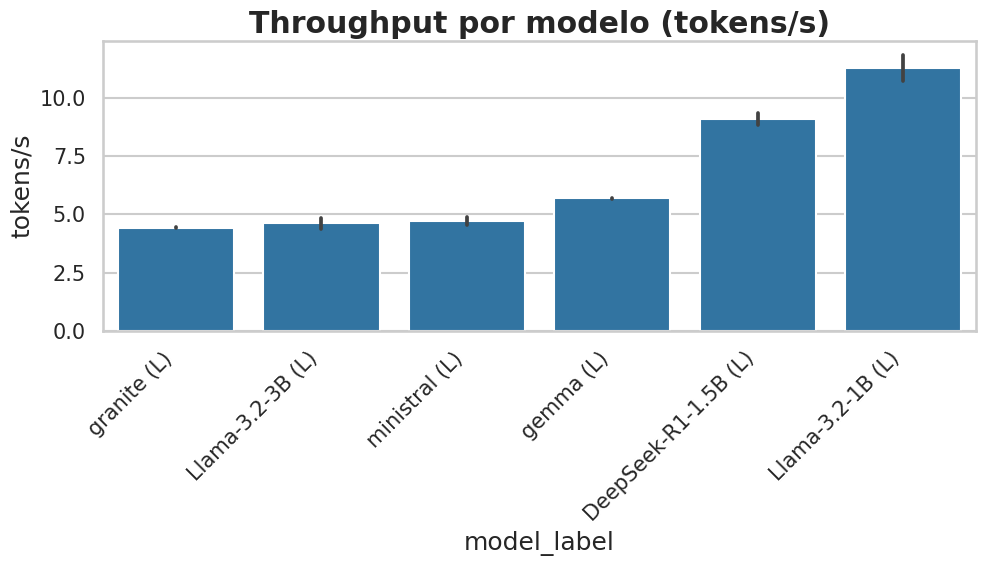

/tmp/ipykernel_729383/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


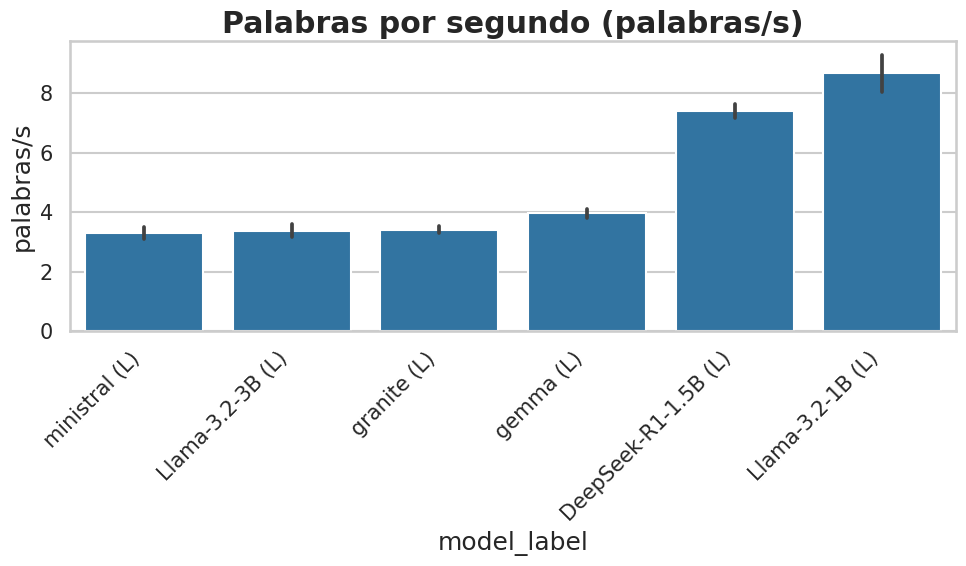

/tmp/ipykernel_729383/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


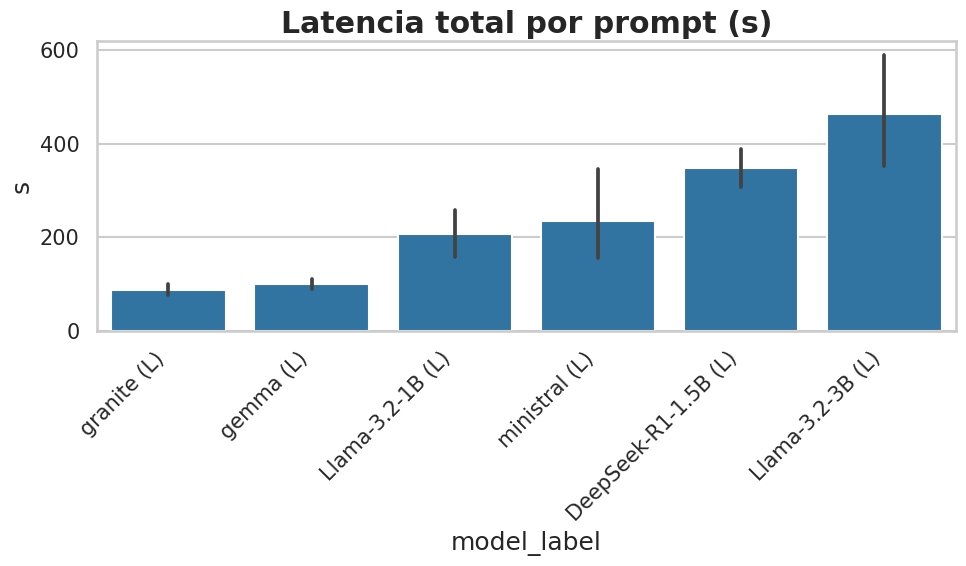

/tmp/ipykernel_729383/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


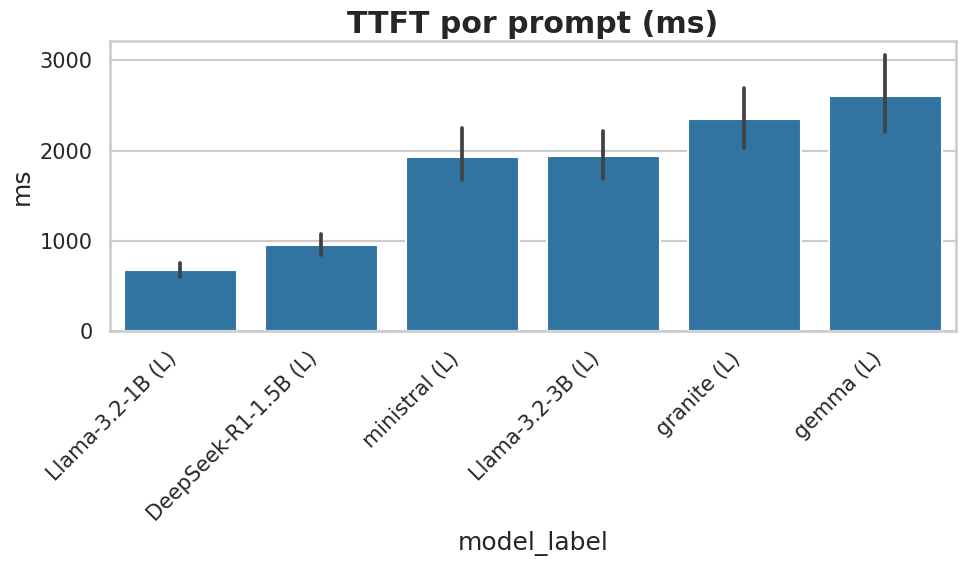

/tmp/ipykernel_729383/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


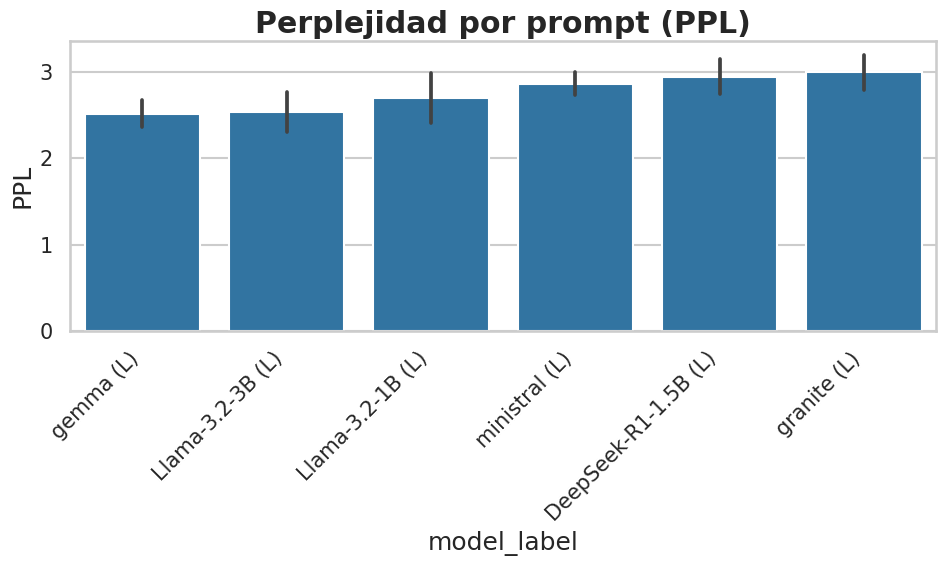

In [13]:
# Métricas de inferencia por modelo
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput por modelo",
                 unit_label="tokens/s")
    _plot_metric(pm_valid, "words_per_second", "palabras/s", "Palabras por segundo",
                 unit_label="palabras/s")
    _plot_metric(pm_valid, "latency_ms", "ms", "Latencia total por prompt",
                 unit_divisor=1000, unit_label="s")
    _plot_metric(pm_valid, "time_to_first_token_ms", "ms", "TTFT por prompt",
                 unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric(ppl_valid, "perplexity", "", "Perplejidad por prompt",
                     unit_label="PPL")
else:
    print("Sin datos de inferencia")

/tmp/ipykernel_729383/2257969231.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


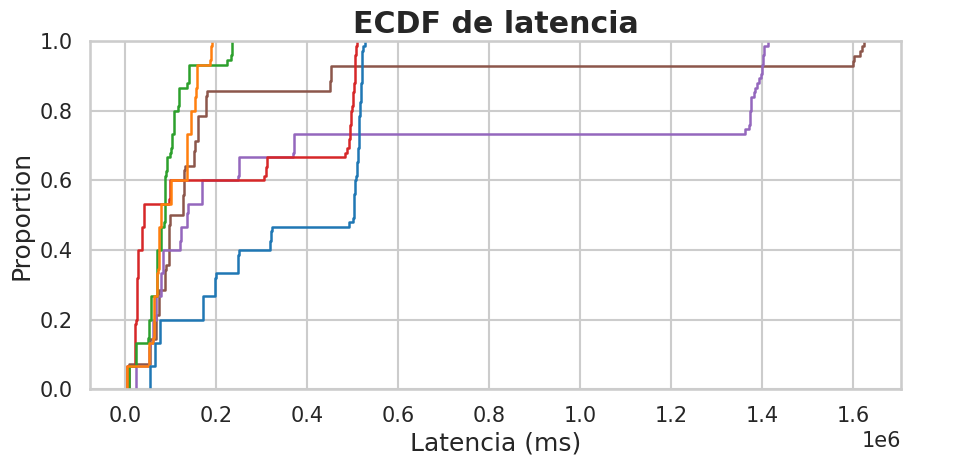

/tmp/ipykernel_729383/2257969231.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


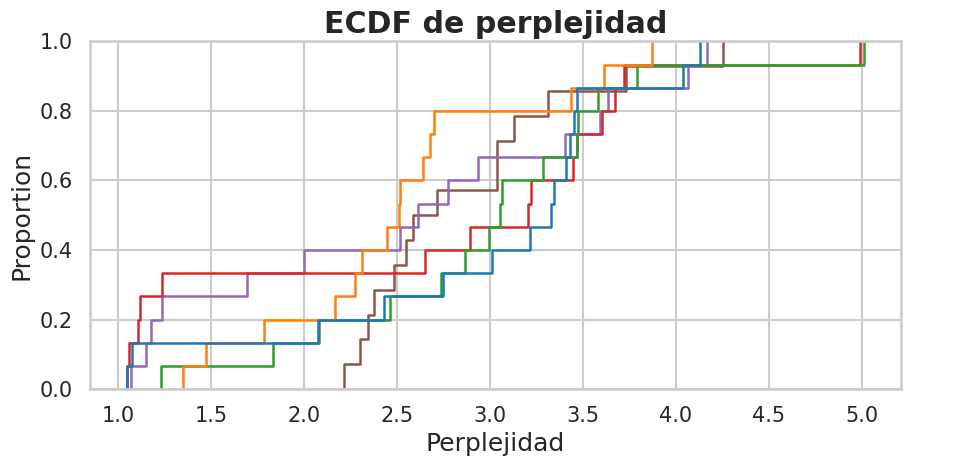

In [14]:
# ECDFs de latencia y perplejidad
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=pm_valid, x="latency_ms", hue="model_label", ax=ax)
    ax.set_title("ECDF de latencia")
    ax.set_xlabel("Latencia (ms)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
        ax.set_title("ECDF de perplejidad")
        ax.set_xlabel("Perplejidad")
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
else:
    print("Sin datos para ECDFs")

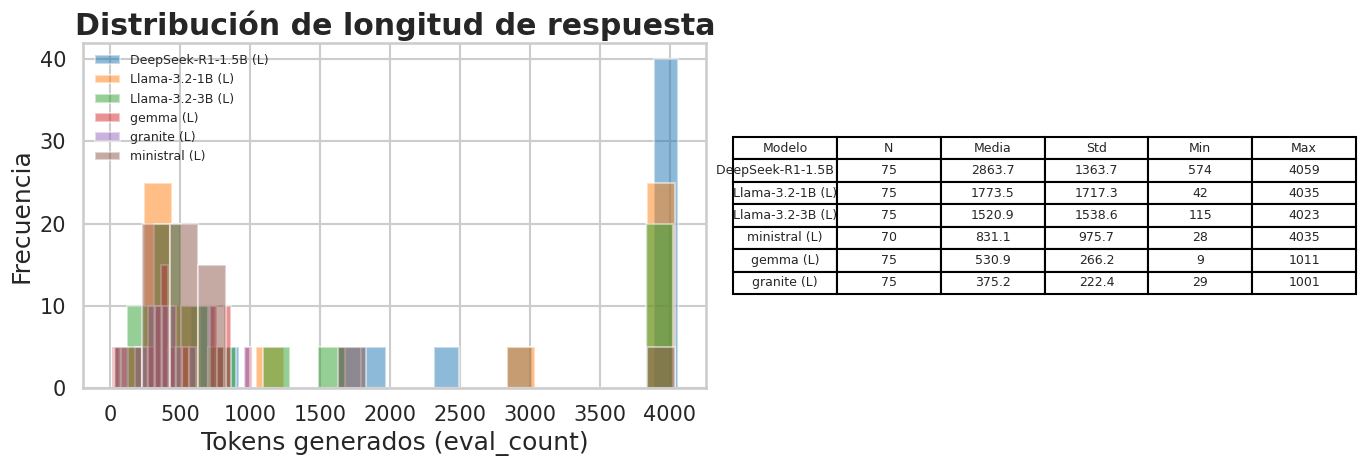

In [15]:
# Distribución de longitud de respuesta
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model in sorted(pm_valid["model_label"].unique()):
        sub = pm_valid[pm_valid["model_label"] == model]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=model)
    axes[0].set_xlabel("Tokens generados (eval_count)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de respuesta")
    axes[0].legend(fontsize=9)
    summary_resp = pm_valid.groupby("model_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Modelo", "N", "Media", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para distribución de longitud de respuesta")

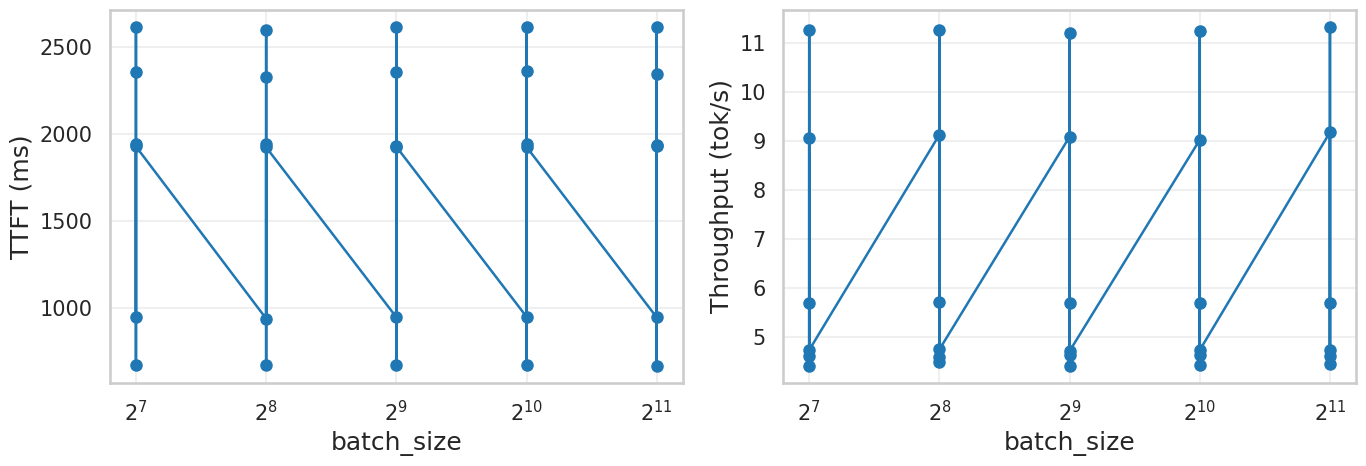

Nota: El throughput de decode no debería variar con batch_size.


In [16]:
# Análisis específico E3: Batch size sensitivity
try:
    from monitorviz.viz import sensitivity_curve
    e3_ok = not ex.empty and "batch_size" in ex.columns and ex["batch_size"].nunique() >= 2
    if e3_ok:
        fig = sensitivity_curve(ex, param_col="batch_size", metrics=[
            ("ttft_ms_mean", "TTFT (ms)"),
            ("tokens_per_s_mean", "Throughput (tok/s)"),
        ], log_x=True)
        plt.show()
        print("Nota: El throughput de decode no debería variar con batch_size.")
    else:
        print("Sin datos de batch_size")
except Exception as e:
    print(f"Error sensitivity_curve: {e}")

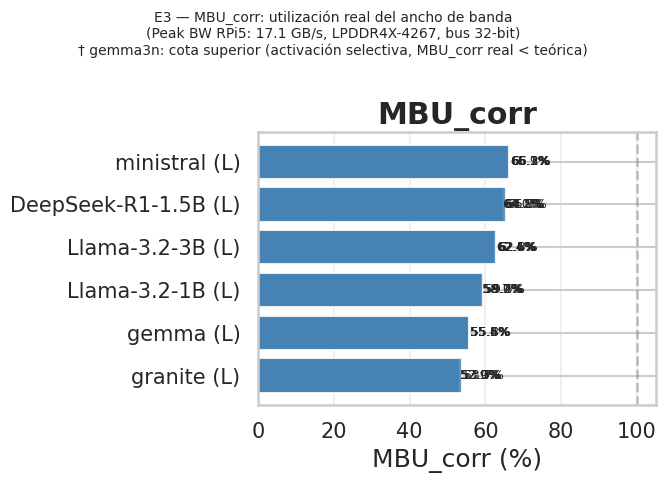

Correcciones aplicadas:


,model_label,mbu_corr,mbu_corr_notes
0,DeepSeek-R1-1.5B (L),64.25,dense
1,gemma (L),55.41,Gemma 3n MatFormer: N_params_act=1.910B (verif...
2,granite (L),52.88,"Granite SSM hybrid: M_state=74.4 MiB, L_ssm=36..."
3,Llama-3.2-1B (L),58.97,dense
4,Llama-3.2-3B (L),62.45,dense
5,ministral (L),66.12,dense


In [17]:
# MBU_corr — Memory Bandwidth Utilization (arquitectura corregida)
from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

_mbu_col = "mbu_corr" if "mbu_corr" in ex.columns else (
           "mbu_pct"  if "mbu_pct"  in ex.columns else None)

if _mbu_col is not None:
    mbu_data = ex.dropna(subset=[_mbu_col]).copy()
    if not mbu_data.empty:
        has_fan = "fan" in mbu_data.columns and mbu_data["fan"].nunique() > 1
        fan_groups = (
            [(True, "Con ventilador (FAN)", "steelblue"),
             (False, "Sin ventilador (NOFAN)", "tomato")]
            if has_fan else [(None, "MBU_corr", "steelblue")]
        )
        fig, axes = plt.subplots(1, len(fan_groups),
                                  figsize=(7 * len(fan_groups), 5), sharey=False)
        if len(fan_groups) == 1:
            axes = [axes]
        for ax, (fan_val, lbl, color) in zip(axes, fan_groups):
            sub = (mbu_data[mbu_data["fan"] == fan_val]
                   if fan_val is not None else mbu_data).copy()
            sub = sub.sort_values(_mbu_col)
            if sub.empty:
                ax.set_axis_off(); continue
            ax.barh(sub["model_label"], sub[_mbu_col], color=color, alpha=0.85)
            ax.axvline(100, ls="--", color="gray", alpha=0.5)
            ax.set_xlabel("MBU_corr (%)")
            ax.set_title(lbl)
            ax.grid(True, axis="x", alpha=0.3)
            for bar, val in zip(ax.patches, sub[_mbu_col]):
                ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                        f"{val:.1f}%", va="center", fontsize=9)
        fig.suptitle(
            f"E3 — MBU_corr: utilización real del ancho de banda\n"
            f"(Peak BW RPi5: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s, LPDDR4X-4267, bus 32-bit)\n"
            "† gemma3n: cota superior (activación selectiva, MBU_corr real < teórica)",
            fontsize=10)
        plt.tight_layout()
        plt.show()
        if "mbu_corr_notes" in mbu_data.columns:
            notes = (mbu_data[["model_label","mbu_corr","mbu_corr_notes"]]
                     .drop_duplicates("model_label").round(2))
            print("Correcciones aplicadas:")
            display(notes)
else:
    print("mbu_corr no disponible en este experimento.")


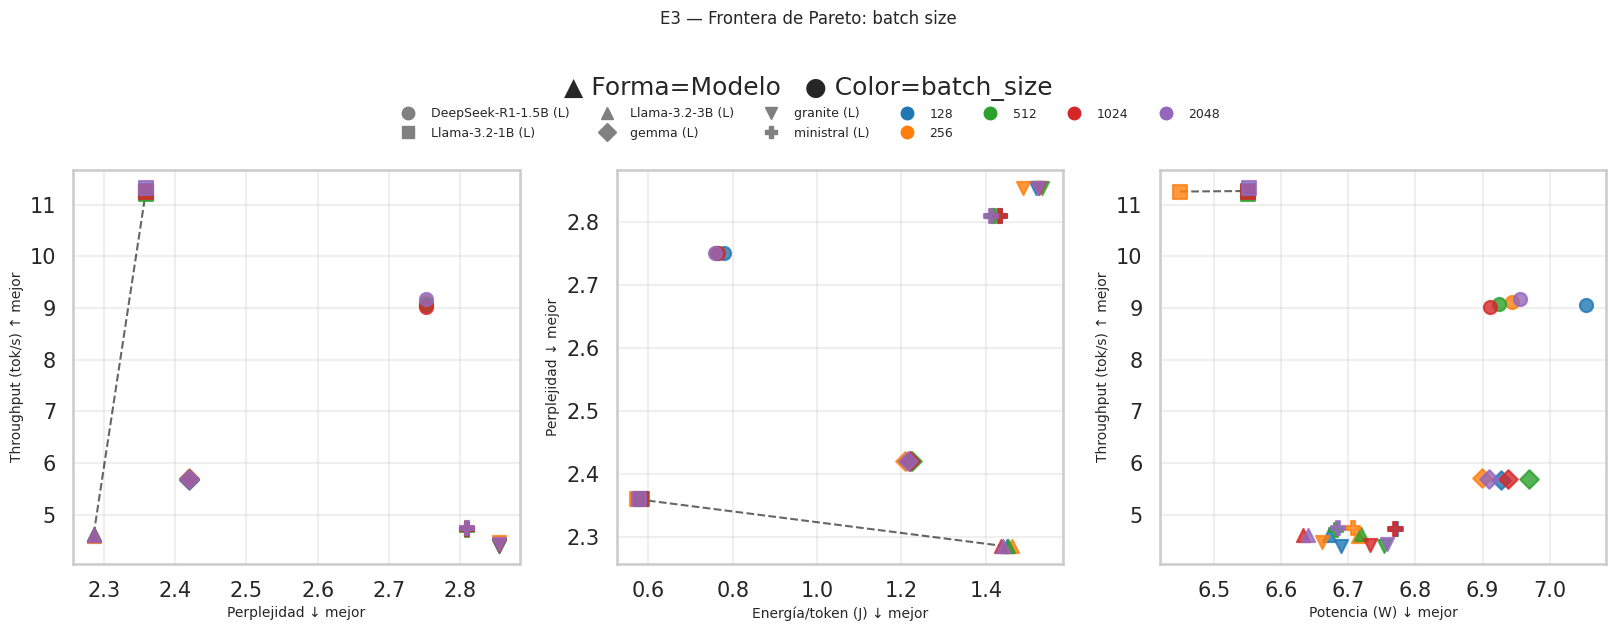

In [18]:
# Trade-offs multidimensionales — Frontera de Pareto (E3)
from matplotlib.lines import Line2D as _L2D

def _pmask(df, x_col, y_col, x_low, y_low):
    pts = df[[x_col, y_col]].to_numpy(dtype=float)
    dom = np.zeros(len(pts), dtype=bool)
    for i in range(len(pts)):
        for j in range(len(pts)):
            if i == j: continue
            xb = (pts[j,0] <= pts[i,0]) if x_low else (pts[j,0] >= pts[i,0])
            yb = (pts[j,1] <= pts[i,1]) if y_low else (pts[j,1] >= pts[i,1])
            if xb and yb and (pts[j,0] != pts[i,0] or pts[j,1] != pts[i,1]):
                dom[i] = True; break
    return ~dom

_pareto_pairs_e3 = [
    ("perplexity_geomean", "tokens_per_s_mean",  True,  False, "Perplejidad",       "Throughput (tok/s)"),
    ("energy_per_token_j", "perplexity_geomean",  True,  True,  "Energía/token (J)", "Perplejidad"),
    ("power_mean_w",       "tokens_per_s_mean",   True,  False, "Potencia (W)",      "Throughput (tok/s)"),
]
valid_pairs_e3 = [(xc,yc,xl,yl,xlab,ylab) for xc,yc,xl,yl,xlab,ylab in _pareto_pairs_e3
                  if xc in ex.columns and yc in ex.columns]

if valid_pairs_e3 and not ex.empty:
    _models_p3 = sorted(ex["model_label"].unique())
    _MARKERS_P = ["o","s","^","D","v","P","X"]
    _MOD_MK_P  = {m: _MARKERS_P[i % len(_MARKERS_P)] for i, m in enumerate(_models_p3)}

    _batches_p = sorted(ex["batch_size"].dropna().unique()) if "batch_size" in ex.columns else []
    _BS_COLORS = dict(zip(
        _batches_p,
        ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown"][:len(_batches_p)]
    ))

    nc = len(valid_pairs_e3)
    fig, axes = plt.subplots(1, nc, figsize=(nc * 5.5, 5.5))
    if nc == 1: axes = [axes]

    for ax, (xc, yc, xl, yl, xlabel, ylabel) in zip(axes, valid_pairs_e3):
        df_p = ex.dropna(subset=[xc, yc]).reset_index(drop=True)
        if df_p.empty: ax.set_visible(False); continue

        for model in _models_p3:
            for bs in _batches_p:
                _sub = df_p[(df_p["model_label"]==model) & (df_p["batch_size"]==bs)]
                if _sub.empty: continue
                ax.scatter(_sub[xc], _sub[yc],
                           marker=_MOD_MK_P[model],
                           color=_BS_COLORS.get(bs, "tab:gray"),
                           s=90, alpha=0.8, zorder=3)

        mask = _pmask(df_p, xc, yc, xl, yl)
        df_front = df_p[mask].sort_values(xc)
        if not df_front.empty:
            ax.plot(df_front[xc], df_front[yc], "k--", lw=1.5, alpha=0.6)

        ax.set_xlabel(xlabel + (" ↓ mejor" if xl else " ↑ mejor"), fontsize=10)
        ax.set_ylabel(ylabel + (" ↓ mejor" if yl else " ↑ mejor"), fontsize=10)
        ax.grid(True, alpha=0.3)

    _mod_handles_p = [_L2D([],[],marker=_MOD_MK_P[m],color="gray",ls="none",ms=9,label=m) for m in _models_p3]
    _bs_handles_p  = [_L2D([],[],marker="o",color=_BS_COLORS.get(bs,"tab:gray"),ls="none",ms=9,label=str(int(bs))) for bs in _batches_p]

    fig.legend(
        handles=_mod_handles_p + _bs_handles_p,
        loc="upper center", bbox_to_anchor=(0.5, 1.06),
        ncol=min(len(_models_p3) + len(_batches_p), 7), fontsize=9,
        title="▲ Forma=Modelo   ● Color=batch_size"
    )
    fig.suptitle("E3 — Frontera de Pareto: batch size", fontsize=12, y=1.16)
    fig.tight_layout()
    plt.show()
else:
    print("Columnas insuficientes para Pareto")


In [19]:
# Desglose de fases (si hay datos)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("Sin datos de fases")
except Exception as e:
    print(f"Error en phase_breakdown: {e}")

Sin datos de fases


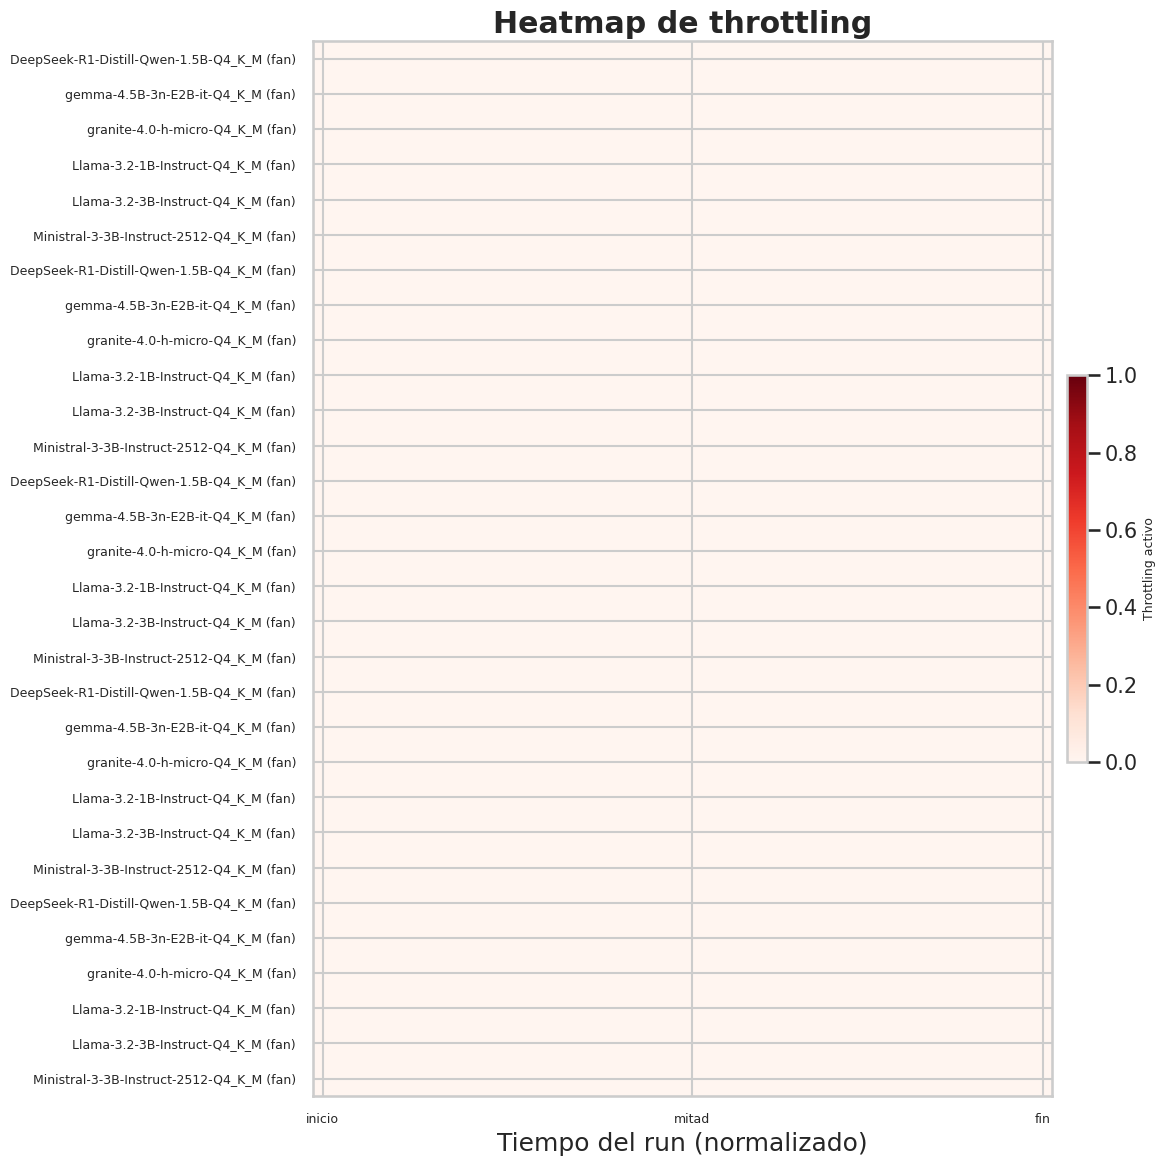

In [20]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("Sin datos de hardware para heatmap de throttling")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Heatmap de throttling")
        plt.show()
except Exception as e:
    print(f"Error en throttling_heatmap: {e}")

## Eficiencia computacional: trabajo CPU efectivo

- **W_CPU (core·s)**: integra `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), rango [0,1]
- **W_token (core·s/token)**: trabajo CPU por token generado

/tmp/ipykernel_729383/1471974482.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


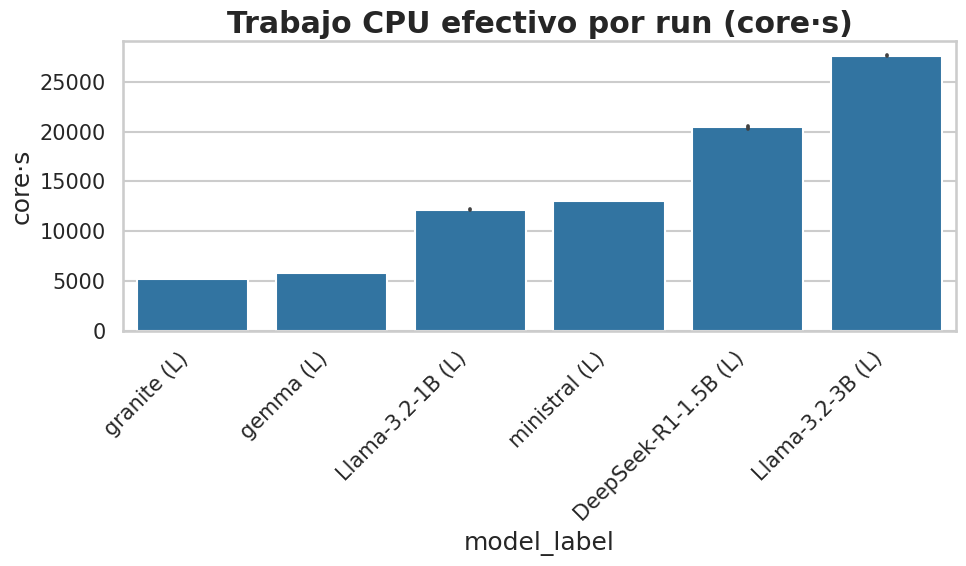

/tmp/ipykernel_729383/1471974482.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


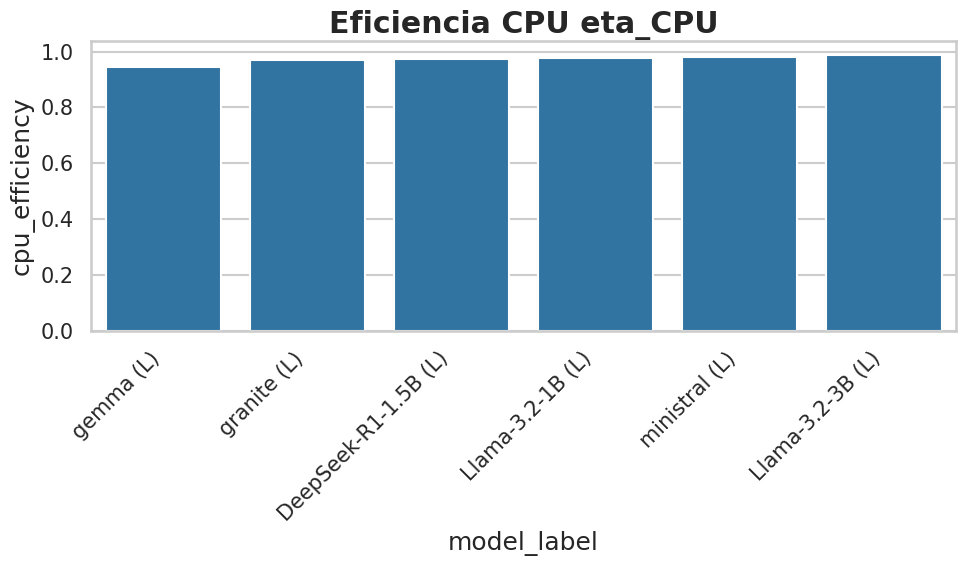

/tmp/ipykernel_729383/1471974482.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


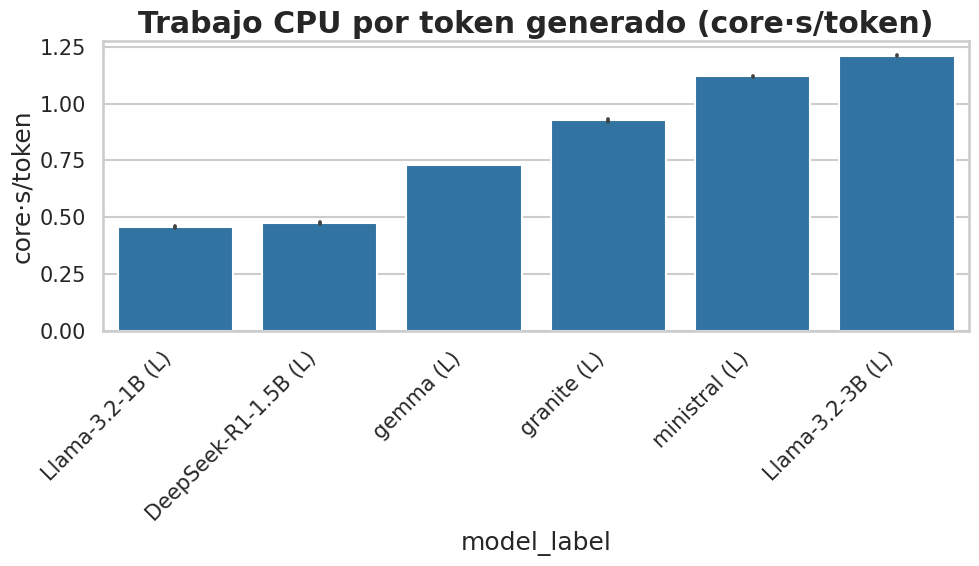

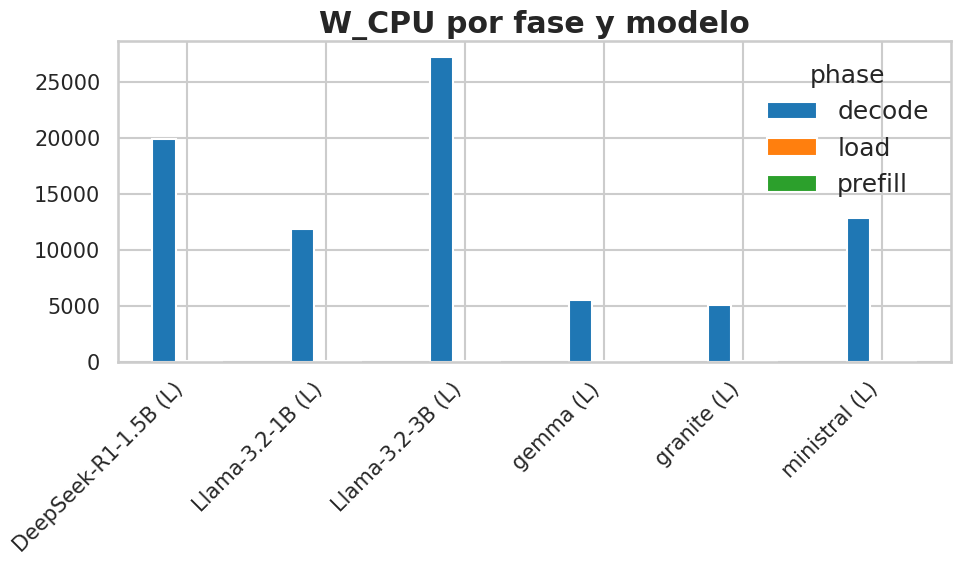

/tmp/ipykernel_729383/1471974482.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


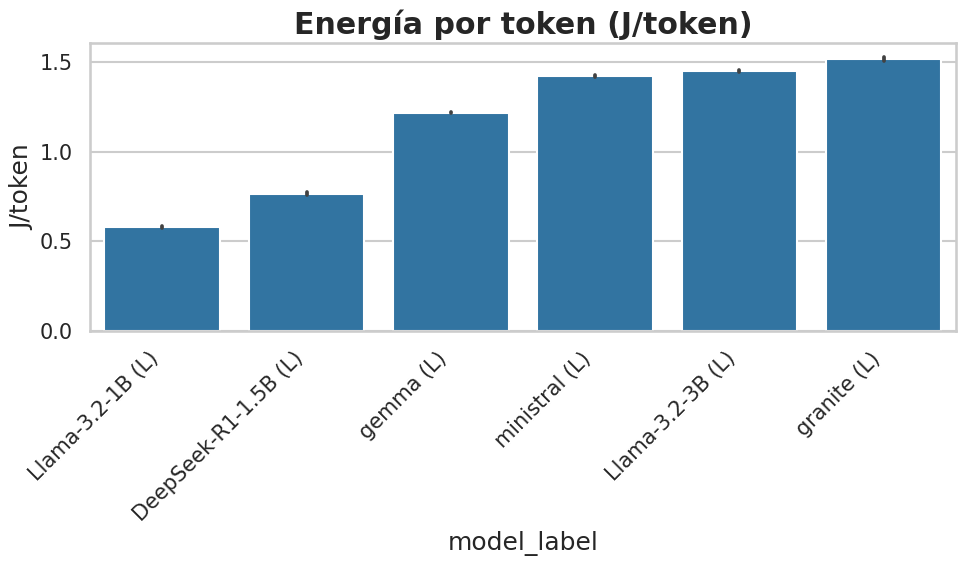

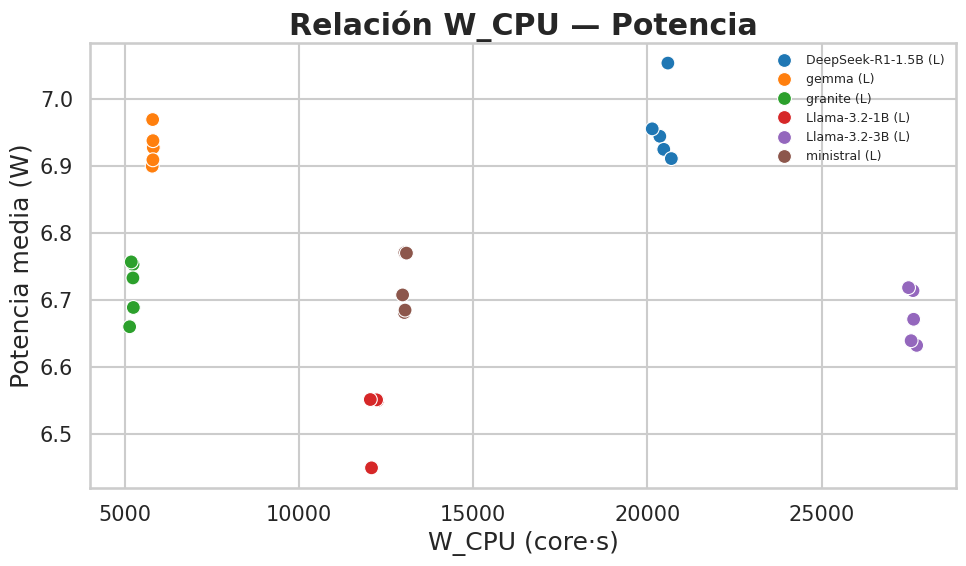

In [21]:
# Eficiencia computacional y energética
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s", "core·s", "Trabajo CPU efectivo por run"),
    ("cpu_efficiency",  "",       "Eficiencia CPU eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "Trabajo CPU por token generado"),
]:
    if col in ex.columns:
        _plot_metric(ex, col, ylabel=ylabel, title=title, unit_label=ylabel)

# Desglose por fases
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        phase_df_ex.groupby(["model_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="bar", ax=ax, rot=45)
        ax.set_title("W_CPU por fase y modelo")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

# Energía por token
if "energy_per_token_j" in ex.columns:
    _plot_metric(ex, "energy_per_token_j", "J/token", "Energía por token", unit_label="J/token")

# Scatterplot CPU vs Potencia
if "cpu_work_core_s" in ex.columns and "power_mean_w" in ex.columns:
    valid_data = ex.dropna(subset=["cpu_work_core_s", "power_mean_w"])
    if not valid_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=valid_data, x="cpu_work_core_s", y="power_mean_w",
                        hue="model_label", s=100, ax=ax)
        ax.set_xlabel("W_CPU (core·s)")
        ax.set_ylabel("Potencia media (W)")
        ax.set_title("Relación W_CPU — Potencia")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

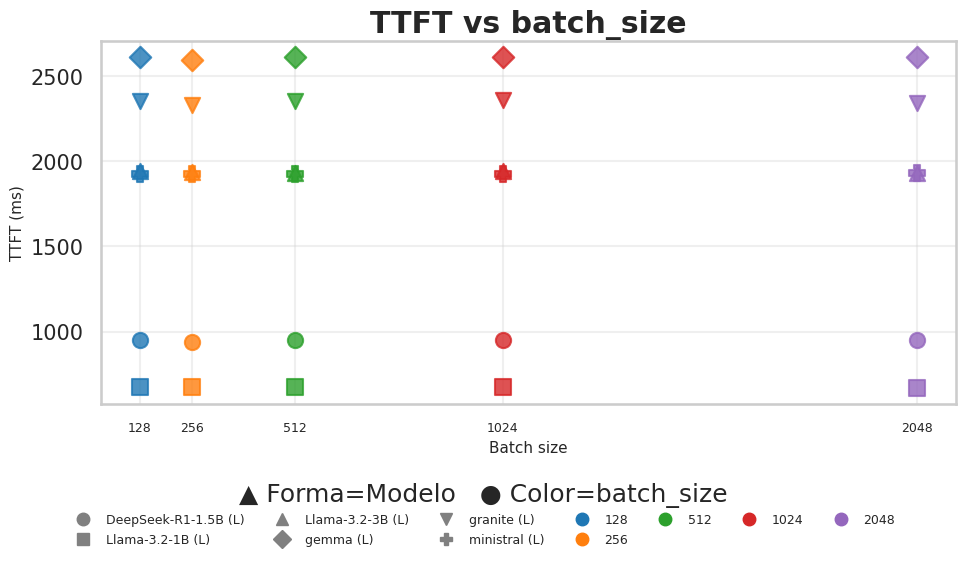

In [22]:
# Rendimiento vs batch_size (E3)
from matplotlib.lines import Line2D as _L2D

if "batch_size" in ex.columns and ex["batch_size"].notna().any():
    batch_data = ex.dropna(subset=["batch_size", "ttft_ms_mean"]).copy()

    _models_sc = sorted(batch_data["model_label"].unique())
    _MARKERS_SC = ["o","s","^","D","v","P","X"]
    _MOD_MK_SC  = {m: _MARKERS_SC[i % len(_MARKERS_SC)] for i, m in enumerate(_models_sc)}

    _batches_sc = sorted(batch_data["batch_size"].dropna().unique())
    _BS_COL_SC  = dict(zip(
        _batches_sc,
        ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown"][:len(_batches_sc)]
    ))

    fig, ax = plt.subplots(figsize=(10, 5))

    for model in _models_sc:
        for bs in _batches_sc:
            _sub = batch_data[(batch_data["model_label"]==model) & (batch_data["batch_size"]==bs)]
            if _sub.empty: continue
            ax.scatter(_sub["batch_size"], _sub["ttft_ms_mean"],
                       marker=_MOD_MK_SC[model],
                       color=_BS_COL_SC.get(bs, "tab:gray"),
                       s=120, alpha=0.8, zorder=3)

    ax.set_xticks(_batches_sc)
    ax.set_xticklabels([str(int(b)) for b in _batches_sc], fontsize=9)
    ax.set_xlabel("Batch size", fontsize=11)
    ax.set_ylabel("TTFT (ms)", fontsize=11)
    ax.set_title("TTFT vs batch_size")
    ax.grid(True, alpha=0.3)

    _mod_h_sc = [_L2D([],[],marker=_MOD_MK_SC[m],color="gray",ls="none",ms=9,label=m) for m in _models_sc]
    _bs_h_sc  = [_L2D([],[],marker="o",color=_BS_COL_SC.get(bs,"tab:gray"),ls="none",ms=9,label=str(int(bs))) for bs in _batches_sc]
    fig.legend(
        handles=_mod_h_sc + _bs_h_sc,
        loc="lower center", bbox_to_anchor=(0.5, -0.15),
        ncol=min(len(_models_sc) + len(_batches_sc), 7), fontsize=9,
        title="▲ Forma=Modelo   ● Color=batch_size"
    )
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos batch_size para scatter")


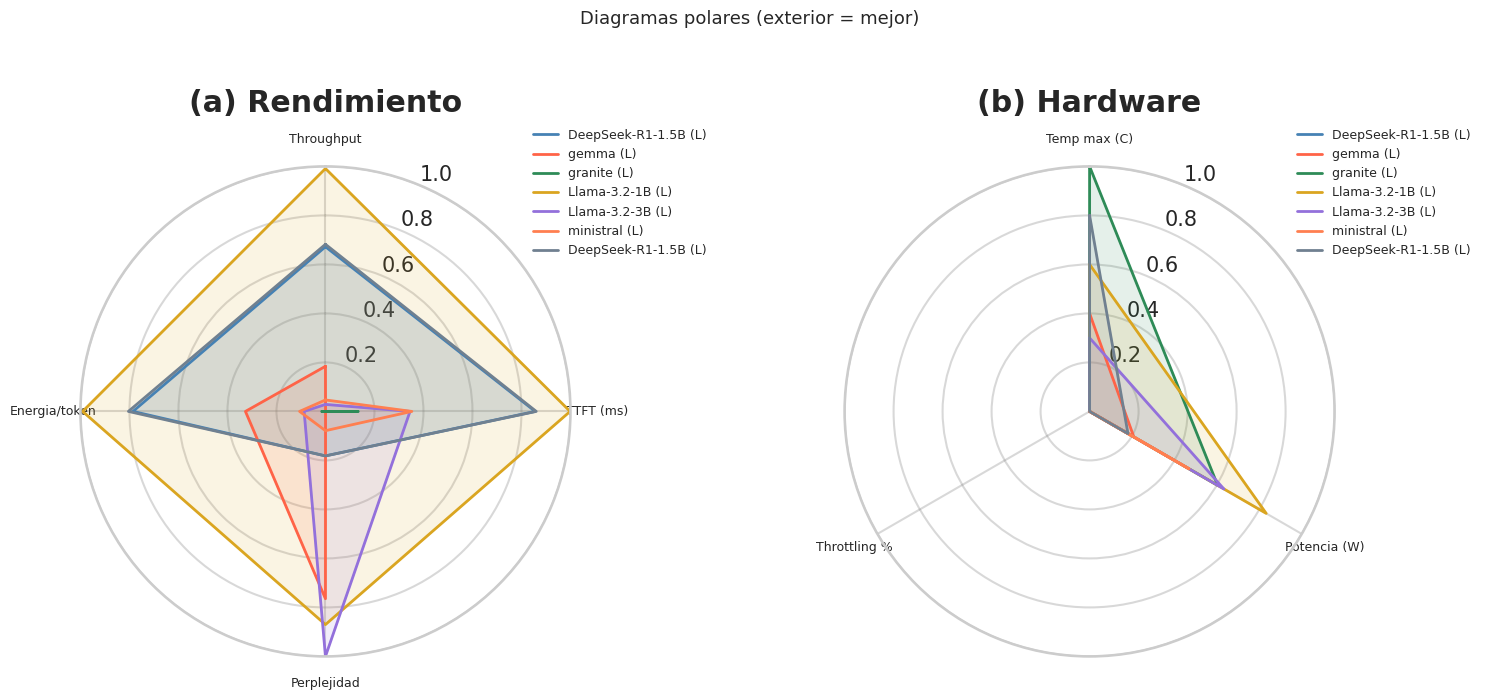

In [23]:
# Diagramas polares (rendimiento y hardware)
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold")
    for (_, row), color in zip(data.iterrows(), colors[:len(data)]):
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            vals.append((data.loc[row.name, col] - col_min) / rng if higher_is_better
                        else (col_max - data.loc[row.name, col]) / rng)
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

perf_metrics = [
    ("tokens_per_s_mean",  "Throughput",      True),
    ("ttft_ms_mean",       "TTFT (ms)",        False),
    ("perplexity_geomean", "Perplejidad",      False),
    ("energy_per_token_j", "Energia/token",    False),
]
hw_metrics_radar = [
    ("temp_max_c",      "Temp max (C)", False),
    ("power_mean_w",    "Potencia (W)", False),
    ("throttled_ratio", "Throttling %", False),
]
colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "coral", "slategray"]
fig = plt.figure(figsize=(16, 7))
perf_avail = [m for m in perf_metrics if m[0] in ex.columns]
hw_avail   = [m for m in hw_metrics_radar if m[0] in ex.columns]
if perf_avail:
    ax1 = fig.add_subplot(121, polar=True)
    _radar_chart(ex, perf_avail, "(a) Rendimiento", ax1, colors_radar)
if hw_avail:
    ax2 = fig.add_subplot(122, polar=True)
    _radar_chart(ex, hw_avail, "(b) Hardware", ax2, colors_radar)
fig.suptitle("Diagramas polares (exterior = mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

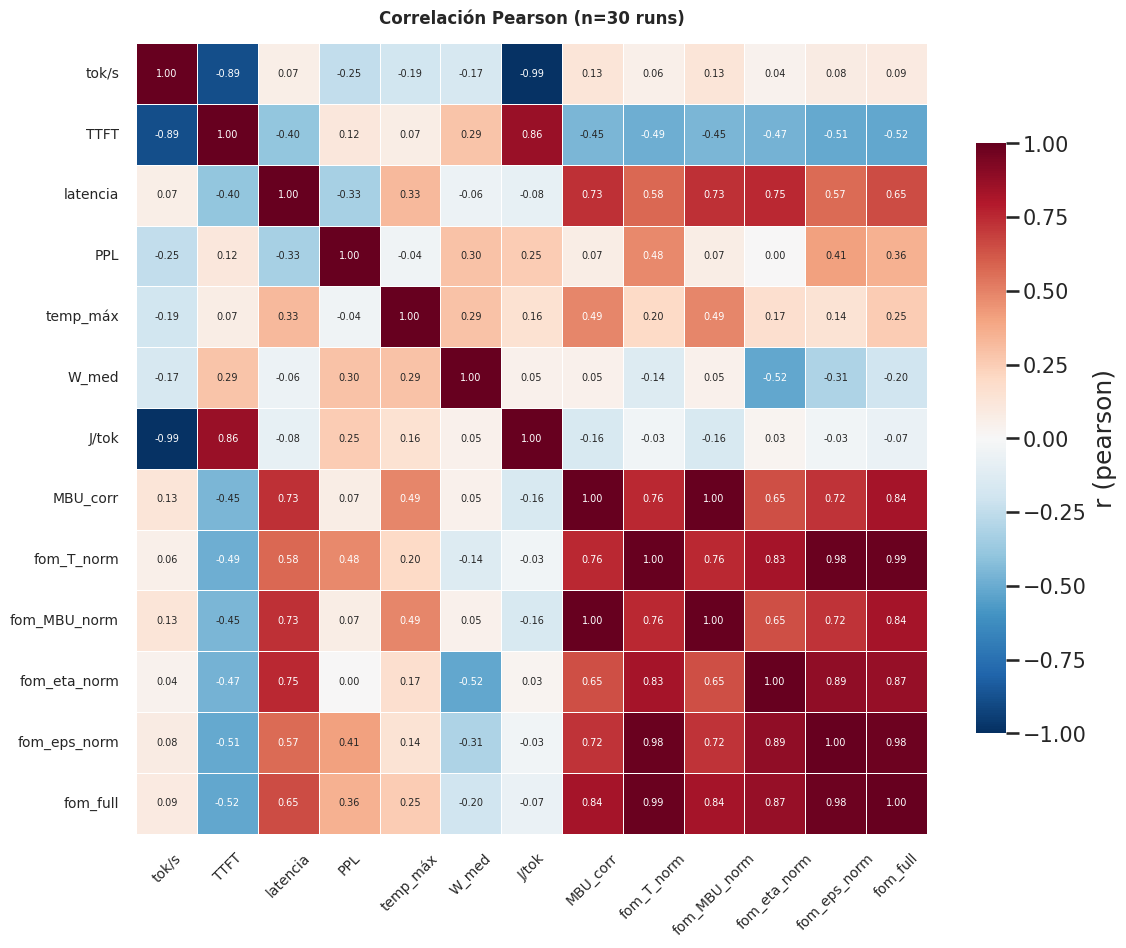

In [24]:
# Correlación de Pearson
try:
    from monitorviz.viz import correlation_heatmap
    from monitorviz.transforms.fom import compute_fom_full
    if len(ex) >= 3:
        _fom_p = compute_fom_full(ex)
        _pearson_cols = [c for c in [
            "tokens_per_s_mean", "ttft_ms_mean", "latency_ms_mean",
            "perplexity_geomean", "temp_max_c", "power_mean_w",
            "energy_per_token_j", "mbu_corr",
            "fom_T_norm", "fom_MBU_norm", "fom_eta_norm", "fom_eps_norm", "fom_full",
        ] if c in _fom_p.columns]
        fig = correlation_heatmap(_fom_p, cols=_pearson_cols,
                                  title=f"Correlación Pearson (n={len(_fom_p)} runs)")
        plt.show()
    else:
        print(f"Datos insuficientes: {len(ex)} run(s), se necesitan >=3.")
except Exception as e:
    print(f"Error en correlación: {e}")


In [25]:
# ── E3 — Tabla de correlaciones: FoM, energía, memoria ──────────────────────
# Correlación de Pearson entre métricas clave de batch_size
try:
    from monitorviz.transforms.fom import compute_fom_full

    _corr_src = compute_fom_full(ex).copy()

    # Añadir RAM desde hw_full
    if not hw_full.empty and "run_id" in hw_full.columns and "mem_used_bytes" in hw_full.columns:
        _ram_c = (hw_full.groupby("run_id")[["mem_used_bytes","mem_pct"]]
                  .max().reset_index())
        _ram_c["mem_used_gb"] = _ram_c["mem_used_bytes"] / 1e9
        _corr_src = _corr_src.merge(_ram_c[["run_id","mem_used_gb","mem_pct"]], on="run_id", how="left")

    _CORR_COLS = {
        "batch_size":        "Batch",
        "tokens_per_s_mean": "tok/s",
        "energy_per_token_j":"J/tok",
        "mem_used_gb":       "RAM (GB)",
        "mem_pct":           "RAM (%)",
        "mbu_corr":          "MBU (%)",
        "fom_T_norm":        r"T_norm",
        "fom_eps_norm":      r"ε_norm",
        "fom_full":          "FoM_full",
    }
    _avail_cols = [c for c in _CORR_COLS if c in _corr_src.columns]
    if len(_avail_cols) >= 3:
        _corr_data = _corr_src[_avail_cols].dropna(how="all")
        _corr_mat  = _corr_data.corr(method="pearson")
        _corr_mat.columns = [_CORR_COLS[c] for c in _avail_cols]
        _corr_mat.index   = [_CORR_COLS[c] for c in _avail_cols]

        # Tabla estilizada
        print("Correlaciones Pearson (FoM, energía, memoria):")
        display(_corr_mat.round(3).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)
                .format("{:.3f}"))

        # Columna clave: correlación con FoM_full
        if "FoM_full" in _corr_mat.columns:
            _fom_col = (_corr_mat["FoM_full"]
                        .drop("FoM_full")
                        .sort_values(key=abs, ascending=False))
            print("\nCorrelación con FoM_full:")
            display(_fom_col.rename("r").to_frame().round(3))
    else:
        print(f"Columnas insuficientes para correlación: {_avail_cols}")
except Exception as e:
    print(f"Error en tabla de correlaciones: {e}")


Correlaciones Pearson (FoM, energía, memoria):


,Batch,tok/s,J/tok,RAM (GB),RAM (%),MBU (%),T_norm,ε_norm,FoM_full
Batch,1.000,0.004,-0.004,-0.003,-0.003,0.017,0.010,0.013,0.012
tok/s,0.004,1.000,-0.990,-0.922,-0.922,0.128,0.061,0.082,0.093
J/tok,-0.004,-0.990,1.000,0.929,0.929,-0.161,-0.031,-0.034,-0.065
RAM (GB),-0.003,-0.922,0.929,1.000,1.000,0.143,0.120,0.134,0.139
RAM (%),-0.003,-0.922,0.929,1.000,1.000,0.143,0.120,0.134,0.139
MBU (%),0.017,0.128,-0.161,0.143,0.143,1.000,0.757,0.723,0.835
T_norm,0.010,0.061,-0.031,0.120,0.120,0.757,1.000,0.985,0.986
ε_norm,0.013,0.082,-0.034,0.134,0.134,0.723,0.985,1.000,0.982
FoM_full,0.012,0.093,-0.065,0.139,0.139,0.835,0.986,0.982,1.000



Correlación con FoM_full:


,r
T_norm,0.986
ε_norm,0.982
MBU (%),0.835
RAM (GB),0.139
RAM (%),0.139
tok/s,0.093
J/tok,-0.065
Batch,0.012


In [26]:
# Alertas y anomalías
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"generaciones vacias: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERTA: {a}")
if not alerts:
    print("Sin alertas detectadas")

ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)
ALERTA: generaciones vacias: ministral (L) (n=1)


## Figura de Mérito (FoM_full)

Combina cuatro ejes normalizados respecto a la configuración de referencia
(**llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512**):

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

| Eje | Normalización | Significado |
|-----|--------------|-------------|
| $T_{norm}$ | $N \cdot T / (N_{ref} T_{ref})$ | Throughput ponderado por tamaño |
| $MBU_{norm}$ | $\text{MBU\_corr} / \text{MBU}_{ref}$ | Utilización de ancho de banda (corregida) |
| $\eta_{norm}$ | $\eta_{CPU} / \eta_{ref}$ | Eficiencia computacional |
| $\varepsilon_{norm}$ | $N \cdot \varepsilon / (N_{ref} \varepsilon_{ref})$ | Tokens/J ponderados por tamaño |

**FoM_full > 1** → la configuración supera a la referencia en media geométrica.

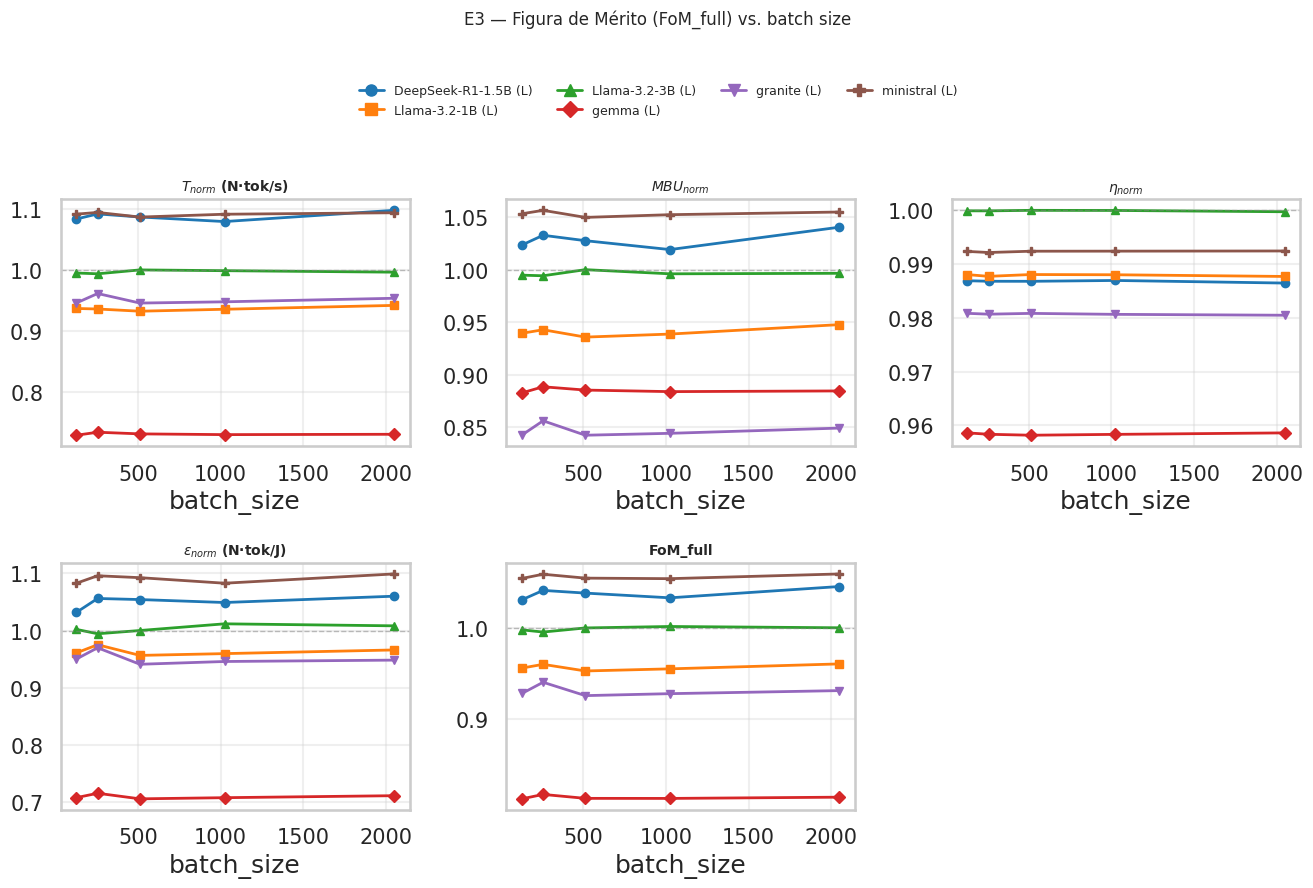

FoM_full por batch size:


,batch_size,model_label,mbu_corr,tokens_per_s_mean,fom_full
0,128,DeepSeek-R1-1.5B (L),64.248,9.053,1.031
1,128,gemma (L),55.407,5.677,0.813
2,128,granite (L),52.885,4.403,0.928
3,128,Llama-3.2-1B (L),58.970,11.262,0.956
4,128,Llama-3.2-3B (L),62.446,4.600,0.998
5,128,ministral (L),66.117,4.726,1.054
6,256,DeepSeek-R1-1.5B (L),64.831,9.122,1.041
7,256,gemma (L),55.772,5.715,0.818
8,256,granite (L),53.737,4.475,0.941
9,256,Llama-3.2-1B (L),59.182,11.252,0.960



Criterio de usabilidad (≥3 palabras/s): 30/30 runs usables


,batch_size,tokens_per_s_mean,T_hum,usable
0,128,9.053,3.691,True
1,128,5.677,4.449,True
2,128,4.403,3.987,True
3,128,11.262,4.416,True
4,128,4.600,4.252,True
5,128,4.726,4.522,True
6,256,9.122,3.691,True
7,256,5.715,4.449,True
8,256,4.475,3.987,True
9,256,11.252,4.416,True


In [27]:
# ── FoM_full — Figura de Mérito compuesta (E3) ─────────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability

_FOM_AXES = {
    "fom_T_norm":   r"$T_{norm}$ (N·tok/s)",
    "fom_MBU_norm": r"$MBU_{norm}$",
    "fom_eta_norm": r"$\eta_{norm}$",
    "fom_eps_norm": r"$\varepsilon_{norm}$ (N·tok/J)",
    "fom_full":     "FoM_full",
}
_x_col = "batch_size"

try:
    fom_df = compute_fom_full(ex)
    avail = [c for c in _FOM_AXES if c in fom_df.columns and fom_df[c].notna().any()]
    if avail:
        _models = sorted(fom_df["model_label"].dropna().unique())
        _MARKERS_F = ["o","s","^","D","v","P","X"]
        _COLORS_F  = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink"]
        _MOD_MK_F  = {m: _MARKERS_F[i % len(_MARKERS_F)] for i, m in enumerate(_models)}
        _MOD_COL_F = {m: _COLORS_F[i  % len(_COLORS_F)]  for i, m in enumerate(_models)}

        _nc = 3
        _nr = (len(avail) + _nc - 1) // _nc
        fig, _axes = plt.subplots(_nr, _nc, figsize=(_nc * 4.5, _nr * 4.0))
        _axes_flat = _axes.flatten() if _nr > 1 else list(_axes)

        for ax, col in zip(_axes_flat, avail):
            for model in _models:
                _sub = fom_df[fom_df["model_label"]==model].dropna(subset=[_x_col, col])
                if _sub.empty: continue
                _sub = _sub.sort_values(_x_col)
                ax.plot(_sub[_x_col], _sub[col],
                        marker=_MOD_MK_F[model], lw=2, ms=6,
                        color=_MOD_COL_F[model], label=model)
            ax.axhline(1.0, ls="--", color="gray", alpha=0.5, lw=1)
            ax.set_title(_FOM_AXES[col], fontsize=10)
            ax.set_xlabel("batch_size")
            ax.grid(True, alpha=0.3)

        for ax in _axes_flat[len(avail):]:
            ax.set_visible(False)

        _handles_f = [
            plt.Line2D([],[],marker=_MOD_MK_F[m],color=_MOD_COL_F[m],lw=2,ms=8,label=m)
            for m in _models
        ]
        fig.legend(handles=_handles_f, loc="upper center",
                   bbox_to_anchor=(0.5, 1.04),
                   ncol=min(len(_models), 4), fontsize=9)
        fig.suptitle("E3 — Figura de Mérito (FoM_full) vs. batch size", fontsize=12, y=1.12)
        fig.tight_layout()
        plt.show()

        _disp = [c for c in [_x_col, "model_label", "mbu_corr", "tokens_per_s_mean", "fom_full"]
                 if c in fom_df.columns]
        print("FoM_full por batch size:")
        display(fom_df[_disp].round(3))
    if not pm_full.empty:
        fom_df, _tpw = compute_usability(fom_df, pm_full)
        n_usable = int(fom_df["usable"].sum()) if "usable" in fom_df.columns else 0
        print(f"\nCriterio de usabilidad (≥3 palabras/s): {n_usable}/{len(fom_df)} runs usables")
        _uc = [c for c in [_x_col, "tokens_per_s_mean", "T_hum", "usable"] if c in fom_df.columns]
        if _uc:
            display(fom_df[_uc].round(3))
except Exception as e:
    print(f"Error en FoM: {e}")


## Conclusiones y discusión

### Confirmación/refutación de hipótesis
> TODO

### Hallazgos principales
> TODO

### Limitaciones
> TODO